# Praktikum Week 03 — Filter Methods dan Wrapper Methods

Notebook ini membahas **feature selection for classification** pada dataset tabular campuran (numerik + kategorikal). Fokus utama praktikum adalah **filter methods** dan **wrapper methods**.


## Tujuan Praktikum

Setelah menyelesaikan notebook ini, mahasiswa diharapkan mampu:

- menyiapkan dataset tabular campuran untuk klasifikasi
- menjelaskan kenapa feature selection penting setelah encoding
- menerapkan beberapa **filter methods**
- menerapkan beberapa **wrapper methods**
- membandingkan hasil seleksi fitur dari berbagai metode
- mengevaluasi trade-off antara jumlah fitur, performa model, dan biaya komputasi


## Struktur Praktikum

1. Load dataset dan pahami struktur kolom
2. Preprocessing dan encoding
3. Baseline model
4. Filter methods
5. Wrapper methods
6. Perbandingan hasil
7. Latihan mandiri


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    SelectPercentile,
    GenericUnivariateSelect,
    f_classif,
    mutual_info_classif,
    chi2,
    SequentialFeatureSelector,
    RFE
)

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 140)
plt.style.use('default')


## 0. Landasan Matematika Filter Methods

### 0.1 Variance Threshold

**Rumus Variance:**

$$\text{Var}(X) = \frac{1}{n} \sum_{i=1}^{n} (x_i - \mu)^2$$

dimana:
- $x_i$ = nilai observasi ke-$i$
- $\mu$ = mean dari fitur
- $n$ = jumlah observasi

**Kriteria Seleksi:**
$$\text{Pertahankan fitur jika } \text{Var}(X) > \text{threshold}$$

---

### 0.2 ANOVA F-test (`f_classif`)

**F-statistic untuk One-Way ANOVA:**

$$F = \frac{\text{Variance Between Groups}}{\text{Variance Within Groups}} = \frac{MS_{between}}{MS_{within}}$$

$$MS_{between} = \frac{SS_{between}}{k-1}, \quad MS_{within} = \frac{SS_{within}}{N-k}$$

$$SS_{between} = \sum_{j=1}^{k} n_j (\bar{x}_j - \bar{x})^2$$

$$SS_{within} = \sum_{j=1}^{k} \sum_{i=1}^{n_j} (x_{ij} - \bar{x}_j)^2$$

dimana:
- $k$ = jumlah kelas
- $n_j$ = jumlah sampel di kelas $j$
- $\bar{x}_j$ = mean fitur di kelas $j$
- $\bar{x}$ = grand mean (mean keseluruhan)
- $N$ = total sampel

**p-value:**
$$p = P(F_{k-1, N-k} > F_{observed})$$

**Kriteria Seleksi:**
- F-score tinggi → perbedaan mean antarkelas besar → fitur informatif
- p-value kecil (< 0.05) → perbedaan signifikan secara statistik

---

### 0.3 Chi-Square Test (`chi2`)

**Chi-Square Statistic:**

$$\chi^2 = \sum_{i=1}^{r} \sum_{j=1}^{c} \frac{(O_{ij} - E_{ij})^2}{E_{ij}}$$

dimana:
- $O_{ij}$ = observed frequency (frekuensi observasi) di sel $(i,j)$
- $E_{ij}$ = expected frequency (frekuensi harapan) di sel $(i,j)$
- $r$ = jumlah baris (kategori fitur)
- $c$ = jumlah kolom (kategori target)

**Expected Frequency:**
$$E_{ij} = \frac{(\text{row total}_i) \times (\text{column total}_j)}{N}$$

**Degrees of Freedom:**
$$df = (r-1)(c-1)$$

**p-value:**
$$p = P(\chi^2_{df} > \chi^2_{observed})$$

**Kriteria Seleksi:**
- $\chi^2$ tinggi → asosiasi kuat antara fitur dan target
- p-value < 0.05 → asosiasi signifikan secara statistik

**Syarat:** Semua nilai fitur harus **non-negative**.

---

### 0.4 Mutual Information

**Mutual Information untuk Diskret:**

$$I(X; Y) = \sum_{x \in X} \sum_{y \in Y} p(x,y) \log\left(\frac{p(x,y)}{p(x)p(y)}\right)$$

dimana:
- $p(x,y)$ = joint probability
- $p(x)$, $p(y)$ = marginal probabilities

**Interpretasi:**
- $I(X; Y) = 0$ → X dan Y independen
- $I(X; Y)$ tinggi → X dan Y sangat dependent

**Untuk Kontinu:**
Estimasi menggunakan k-nearest neighbors (KSG estimator):

$$I(X; Y) \approx \psi(k) - \langle \psi(n_x + 1) + \psi(n_y + 1) \rangle + \psi(N)$$

dimana $\psi$ adalah digamma function, $k$ adalah jumlah tetangga, $n_x$ dan $n_y$ adalah jumlah tetangga dalam proyeksi X dan Y.

**Kelebihan:** Dapat menangkap hubungan **non-linear**, tidak seperti F-test yang hanya menangkap hubungan linear-ish.

---

### 0.5 SelectKBest dan SelectPercentile

Bukan metode scoring, tetapi **selector** yang memilih fitur berdasarkan ranking score dari fungsi scoring ($f_{classif}$, $chi2$, $mutual\_info$, dll).

**SelectKBest:**
$$\text{Pilih } k \text{ fitur dengan score tertinggi}$$

**SelectPercentile:**
$$\text{Pilih } p\% \text{ fitur dengan score tertinggi}$$

---

### 0.6 Wrapper Methods — Sequential Feature Selection

**Objective Function:**

$$J(S) = \text{Score}(\text{Model}(S))$$

dimana $S$ adalah subset fitur, dan Score bisa accuracy, F1-score, AUC, dll.

**Sequential Forward Selection (SFS):**

1. Mulai dari $S = \emptyset$
2. Untuk setiap fitur $f \notin S$:
   - Hitung $J(S \cup \{f\})$
3. Pilih $f^* = \arg\max_{f} J(S \cup \{f\})$
4. Update $S = S \cup \{f^*\}$
5. Ulangi sampai $|S| = k$

**Sequential Backward Selection (SBS):**

1. Mulai dari $S = $ semua fitur
2. Untuk setiap fitur $f \in S$:
   - Hitung $J(S \setminus \{f\})$
3. Pilih $f^* = \arg\min_{f} J(S \setminus \{f\})$ (atau $\arg\max$ jika score turun paling sedikit)
4. Update $S = S \setminus \{f^*\}$
5. Ulangi sampai $|S| = k$

---

### 0.7 Wrapper Methods — Recursive Feature Elimination (RFE)

**Algoritma:**

1. Latih model $M$ dengan semua fitur
2. Hitung importance untuk setiap fitur:
   - Untuk linear model: $importance_j = |coef_j|$
   - Untuk tree-based: $importance_j$ dari `feature_importances_`
3. Buang fitur dengan importance terendah
4. Ulangi sampai tersisa $k$ fitur

**Objective:**
$$\text{Minimalkan } \sum_{j \in \text{removed}} importance_j$$

---

> **Catatan:** Filter methods menggunakan kriteria statistik **independen dari model**, sedangkan wrapper methods mengevaluasi subset fitur dengan **melatih model secara langsung**.


## 1. Load Dataset

Dataset utama minggu ini adalah `training_dataset.csv`. Target klasifikasi yang ingin diprediksi adalah `berlangganan_deposito`.


In [2]:
from pathlib import Path
import os

# Use absolute path based on notebook location
notebook_dir = Path('/Users/dans/Downloads/asdos-datmin/week-03/praktikum')

def resolve_dataset(filename):
    # Try notebook directory first
    candidate = notebook_dir / filename
    if candidate.exists():
        return candidate
    
    # Try current working directory
    candidate = Path.cwd() / filename
    if candidate.exists():
        return candidate
    
    # Try Kaggle paths
    kaggle_input = Path('/kaggle/input')
    if kaggle_input.exists():
        matches = list(kaggle_input.rglob(filename))
        if matches:
            return matches[0]
    
    raise FileNotFoundError(f'Tidak menemukan {filename}')

train_path = resolve_dataset('training_dataset.csv')
valid_path = resolve_dataset('validation_set.csv')

print(f'Notebook dir: {notebook_dir}')
print(f'Working dir: {Path.cwd()}')
print(f'Training path: {train_path}')
print(f'Validation path: {valid_path}')

df = pd.read_csv(train_path)
df_valid = pd.read_csv(valid_path)

print('Shape training set :', df.shape)
print('Shape validation set:', df_valid.shape)

df.head()


Notebook dir: /Users/dans/Downloads/asdos-datmin/week-03/praktikum
Working dir: /Users/dans/Downloads/asdos-datmin
Training path: /Users/dans/Downloads/asdos-datmin/week-03/praktikum/training_dataset.csv
Validation path: /Users/dans/Downloads/asdos-datmin/week-03/praktikum/validation_set.csv
Shape training set : (22916, 22)
Shape validation set: (5729, 21)


,customer_number,usia,pekerjaan,status_perkawinan,pendidikan,gagal_bayar_sebelumnya,pinjaman_rumah,pinjaman_pribadi,jenis_kontak,bulan_kontak_terakhir,hari_kontak_terakhir,jumlah_kontak_kampanye_ini,hari_sejak_kontak_sebelumnya,jumlah_kontak_sebelumnya,hasil_kampanye_sebelumnya,tingkat_variasi_pekerjaan,indeks_harga_konsumen,indeks_kepercayaan_konsumen,suku_bunga_euribor_3bln,jumlah_pekerja,pulau,berlangganan_deposito
0,531036,63,sosial media specialis,menikah,Pendidikan Tinggi,no,yes,no,cellular,jul,fri,2,999,0,nonexistent,-1.7,94.215,-40.3,0.885,4991.6,Papua,1
1,999241,43,teknisi,menikah,Pendidikan Tinggi,no,yes,no,cellular,nov,fri,2,999,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,Sulawesi,0
2,995002,29,sosial media specialis,lajang,Pendidikan Tinggi,no,yes,yes,cellular,jul,thu,1,999,0,nonexistent,1.4,93.918,-42.7,4.958,5228.1,Papua,0
3,932750,40,pekerja kasar,menikah,SMA,no,no,no,telephone,may,wed,2,999,0,nonexistent,1.1,93.994,-36.4,4.859,5191.0,Sumatera,1
4,684699,40,sosial media specialis,lajang,Pendidikan Tinggi,no,no,no,cellular,aug,wed,3,999,0,nonexistent,1.4,93.444,-36.1,4.964,5228.1,Bali,0


### Observasi awal

- training set memiliki target `berlangganan_deposito`
- validation set tidak memiliki target
- dataset berisi kombinasi fitur numerik dan kategorikal
- beberapa kolom memiliki nilai `unknown`


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22916 entries, 0 to 22915
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_number               22916 non-null  int64  
 1   usia                          22916 non-null  int64  
 2   pekerjaan                     22916 non-null  object 
 3   status_perkawinan             22916 non-null  object 
 4   pendidikan                    22916 non-null  object 
 5   gagal_bayar_sebelumnya        22916 non-null  object 
 6   pinjaman_rumah                22916 non-null  object 
 7   pinjaman_pribadi              22916 non-null  object 
 8   jenis_kontak                  22916 non-null  object 
 9   bulan_kontak_terakhir         22916 non-null  object 
 10  hari_kontak_terakhir          22916 non-null  object 
 11  jumlah_kontak_kampanye_ini    22916 non-null  int64  
 12  hari_sejak_kontak_sebelumnya  22916 non-null  int64  
 13  j

In [4]:
target_distribution = df['berlangganan_deposito'].value_counts().sort_index()
target_ratio = df['berlangganan_deposito'].value_counts(normalize=True).sort_index()

summary_target = pd.DataFrame({
    'count': target_distribution,
    'proportion': target_ratio.round(4)
})
summary_target


,count,proportion
berlangganan_deposito,,
0,20302,0.8859
1,2614,0.1141


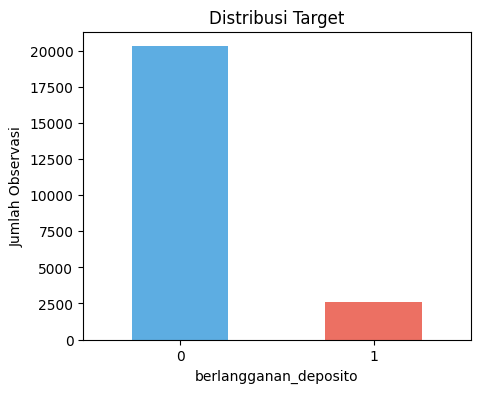

In [5]:
ax = target_distribution.plot(kind='bar', color=['#5dade2', '#ec7063'], figsize=(5, 4))
ax.set_title('Distribusi Target')
ax.set_xlabel('berlangganan_deposito')
ax.set_ylabel('Jumlah Observasi')
plt.xticks(rotation=0)
plt.show()


Dataset ini **tidak seimbang**. Kelas `0` jauh lebih banyak daripada kelas `1`. Ini perlu diingat saat mengevaluasi model — accuracy saja tidak selalu cukup.


## 2. Inspeksi Tipe Fitur

Sebelum melakukan feature selection, kita perlu tahu fitur mana yang numerik, mana yang kategorikal, dan mana yang sebaiknya tidak dipakai langsung sebagai prediktor.


In [6]:
df.dtypes


customer_number                   int64
usia                              int64
pekerjaan                        object
status_perkawinan                object
pendidikan                       object
gagal_bayar_sebelumnya           object
pinjaman_rumah                   object
pinjaman_pribadi                 object
jenis_kontak                     object
bulan_kontak_terakhir            object
hari_kontak_terakhir             object
jumlah_kontak_kampanye_ini        int64
hari_sejak_kontak_sebelumnya      int64
jumlah_kontak_sebelumnya          int64
hasil_kampanye_sebelumnya        object
tingkat_variasi_pekerjaan       float64
indeks_harga_konsumen           float64
indeks_kepercayaan_konsumen     float64
suku_bunga_euribor_3bln         float64
jumlah_pekerja                  float64
pulau                            object
berlangganan_deposito             int64
dtype: object

In [7]:
numeric_columns = [
    'usia',
    'jumlah_kontak_kampanye_ini',
    'hari_sejak_kontak_sebelumnya',
    'jumlah_kontak_sebelumnya',
    'tingkat_variasi_pekerjaan',
    'indeks_harga_konsumen',
    'indeks_kepercayaan_konsumen',
    'suku_bunga_euribor_3bln',
    'jumlah_pekerja'
]

identifier_columns = ['customer_number']
target_column = 'berlangganan_deposito'

categorical_columns = [
    col for col in df.columns
    if col not in numeric_columns + identifier_columns + [target_column]
]

print('Jumlah fitur numerik    :', len(numeric_columns))
print('Jumlah fitur kategorikal:', len(categorical_columns))
print('Kolom ID-like           :', identifier_columns)

print('\nFitur kategorikal:')
for col in categorical_columns:
    print('-', col)


Jumlah fitur numerik    : 9
Jumlah fitur kategorikal: 11
Kolom ID-like           : ['customer_number']

Fitur kategorikal:
- pekerjaan
- status_perkawinan
- pendidikan
- gagal_bayar_sebelumnya
- pinjaman_rumah
- pinjaman_pribadi
- jenis_kontak
- bulan_kontak_terakhir
- hari_kontak_terakhir
- hasil_kampanye_sebelumnya
- pulau


### Catatan penting

Kolom `customer_number` terlihat seperti **identifier**, bukan fitur perilaku atau profil yang memang relevan untuk prediksi. Karena itu, kolom ini akan dibuang dari modeling.


In [8]:
unknown_summary = pd.DataFrame({
    'unknown_count': [(df[col] == 'unknown').sum() if df[col].dtype == 'object' else 0 for col in df.columns]
}, index=df.columns).sort_values('unknown_count', ascending=False)

unknown_summary.head(10)


,unknown_count
gagal_bayar_sebelumnya,4745
pendidikan,992
pinjaman_rumah,579
pinjaman_pribadi,579
pekerjaan,193
status_perkawinan,47
customer_number,0
hasil_kampanye_sebelumnya,0
pulau,0
jumlah_pekerja,0


Nilai `unknown` tidak otomatis dianggap missing value formal (`NaN`), tetapi tetap perlu diperhatikan karena dapat memengaruhi encoding dan interpretasi fitur. Pada praktikum ini, kita **biarkan sebagai kategori valid** agar mahasiswa bisa melihat konsekuensinya setelah one-hot encoding.


## 3. Preprocessing dan Encoding

Pada problem klasifikasi tabular, fitur kategorikal perlu diubah menjadi numerik terlebih dahulu. Untuk transparansi pembelajaran, kita akan memakai `pd.get_dummies()`.


In [9]:
df_model = df.drop(columns=identifier_columns).copy()

X_raw = df_model.drop(columns=[target_column])
y = df_model[target_column].astype(int)

X_encoded = pd.get_dummies(X_raw, columns=categorical_columns, drop_first=False, dtype=int)

print('Shape sebelum encoding :', X_raw.shape)
print('Shape sesudah encoding :', X_encoded.shape)
X_encoded.head()


Shape sebelum encoding : (22916, 20)
Shape sesudah encoding : (22916, 70)


,usia,jumlah_kontak_kampanye_ini,hari_sejak_kontak_sebelumnya,jumlah_kontak_sebelumnya,tingkat_variasi_pekerjaan,indeks_harga_konsumen,indeks_kepercayaan_konsumen,suku_bunga_euribor_3bln,jumlah_pekerja,pekerjaan_asisten rumah tangga,pekerjaan_entrepreneur,pekerjaan_mahasiswa,pekerjaan_manajer,pekerjaan_pekerja kasar,pekerjaan_pemilik bisnis,pekerjaan_pengangguran,pekerjaan_pensiunan,pekerjaan_penyedia jasa,pekerjaan_sosial media specialis,pekerjaan_teknisi,pekerjaan_unknown,status_perkawinan_cerai,status_perkawinan_lajang,status_perkawinan_menikah,status_perkawinan_unknown,pendidikan_Diploma,pendidikan_Pendidikan Tinggi,pendidikan_SD,pendidikan_SMA,pendidikan_SMP,pendidikan_TIDAK SEKOLAH,pendidikan_Tidak Tamat SD,pendidikan_unknown,gagal_bayar_sebelumnya_no,gagal_bayar_sebelumnya_unknown,gagal_bayar_sebelumnya_yes,pinjaman_rumah_no,pinjaman_rumah_unknown,pinjaman_rumah_yes,pinjaman_pribadi_no,pinjaman_pribadi_unknown,pinjaman_pribadi_yes,jenis_kontak_cellular,jenis_kontak_telephone,bulan_kontak_terakhir_apr,bulan_kontak_terakhir_aug,bulan_kontak_terakhir_dec,bulan_kontak_terakhir_jul,bulan_kontak_terakhir_jun,bulan_kontak_terakhir_mar,bulan_kontak_terakhir_may,bulan_kontak_terakhir_nov,bulan_kontak_terakhir_oct,bulan_kontak_terakhir_sep,hari_kontak_terakhir_fri,hari_kontak_terakhir_mon,hari_kontak_terakhir_thu,hari_kontak_terakhir_tue,hari_kontak_terakhir_wed,hasil_kampanye_sebelumnya_failure,hasil_kampanye_sebelumnya_nonexistent,hasil_kampanye_sebelumnya_success,pulau_Bali,pulau_Jawa,pulau_Kalimantan,pulau_NTB,pulau_NTT,pulau_Papua,pulau_Sulawesi,pulau_Sumatera
0,63,2,999,0,-1.7,94.215,-40.3,0.885,4991.6,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0
1,43,2,999,0,-0.1,93.200,-42.0,4.021,5195.8,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0
2,29,1,999,0,1.4,93.918,-42.7,4.958,5228.1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0
3,40,2,999,0,1.1,93.994,-36.4,4.859,5191.0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1
4,40,3,999,0,1.4,93.444,-36.1,4.964,5228.1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0


Setelah encoding, jumlah fitur naik cukup banyak. Inilah titik di mana feature selection menjadi penting.


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Shape X_train:', X_train.shape)
print('Shape X_test :', X_test.shape)


Shape X_train: (18332, 70)
Shape X_test : (4584, 70)


## 4. Baseline Model

Kita mulai dari baseline **Logistic Regression** dengan semua fitur hasil encoding. Nanti semua metode feature selection dibandingkan terhadap baseline ini.


In [11]:
def evaluate_model(model, X_train, X_test, y_train, y_test, method_name, n_features, selected_feature_names):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Calculate ROC-AUC (handle binary and multiclass)
    try:
        y_pred_proba = model.predict_proba(X_test)
        if len(y_pred_proba.shape) == 2 and y_pred_proba.shape[1] == 2:
            roc_auc = roc_auc_score(y_test, y_pred_proba[:, 1])
        else:
            roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='macro')
    except:
        roc_auc = float('nan')
    
    return {
        'method': method_name,
        'n_features': int(n_features),
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'roc_auc': roc_auc,
        'selected_features': list(selected_feature_names)
    }

base_model = LogisticRegression(max_iter=2000, class_weight='balanced')

results = []
feature_sets = {}

baseline_result = evaluate_model(
    base_model,
    X_train,
    X_test,
    y_train,
    y_test,
    method_name='Baseline (all features)',
    n_features=X_train.shape[1],
    selected_feature_names=X_train.columns
)

results.append(baseline_result)
feature_sets['Baseline (all features)'] = list(X_train.columns)

pd.DataFrame(results).drop(columns=['selected_features'])


,method,n_features,accuracy,precision,recall,f1,roc_auc
0,Baseline (all features),70,0.810864,0.33301,0.655832,0.441726,0.788668


In [12]:
print(classification_report(y_test, base_model.fit(X_train, y_train).predict(X_test), digits=4))


              precision    recall  f1-score   support

           0     0.9494    0.8308    0.8861      4061
           1     0.3330    0.6558    0.4417       523

    accuracy                         0.8109      4584
   macro avg     0.6412    0.7433    0.6639      4584
weighted avg     0.8790    0.8109    0.8354      4584



## 5. Filter Methods

Pada bagian ini, kita akan mencoba beberapa pendekatan filter. Intinya: fitur dinilai berdasarkan skor statistik atau properti tertentu, tanpa membungkus model utama secara iteratif.


### 5.1 Variance Threshold

Metode ini membuang fitur dengan variasi yang sangat rendah. Sangat relevan setelah one-hot encoding karena beberapa dummy variables bisa hampir selalu bernilai 0.

**Cocok untuk:**

- fitur numerik
- fitur kategorikal yang sudah di-encoding menjadi dummy / one-hot
- tidak dipakai langsung pada string kategorikal mentah

**Proses:**
1. Hitung variance untuk setiap fitur
2. Bandingkan dengan threshold
3. Buang fitur dengan variance <= threshold

**Output yang akan ditampilkan:**
- Tabel variance per fitur
- Fitur yang lolos threshold


In [13]:
# Hitung variance untuk semua fitur
variance_data = pd.DataFrame({
    'feature': X_train.columns,
    'variance': X_train.var().values
}).sort_values('variance', ascending=False)

print('Statistik Variance:')
print(variance_data.describe())
print('\nSEMUA Fitur berdasarkan Variance (diurutkan):')
display(variance_data)

print('\n--- Seleksi dengan Threshold 0.001 ---')
vt_selector = VarianceThreshold(threshold=0.001)
X_train_vt = vt_selector.fit_transform(X_train)
X_test_vt = vt_selector.transform(X_test)

# Tampilkan fitur yang lolos seleksi
vt_features = X_train.columns[vt_selector.get_support()]
vt_removed = X_train.columns[~vt_selector.get_support()]

print(f'Jumlah fitur sebelum VT : {X_train.shape[1]}')
print(f'Jumlah fitur sesudah VT : {X_train_vt.shape[1]}')
print(f'Jumlah fitur dihapus    : {len(vt_removed)}')

# Tampilkan fitur yang dihapus
if len(vt_removed) > 0:
    print('\nFitur yang dihapus (variance <= 0.001):')
    removed_df = variance_data[variance_data['feature'].isin(vt_removed)].sort_values('variance')
    display(removed_df.head(10))

print('\nContoh fitur yang bertahan:')
print(vt_features[:15].tolist())


Statistik Variance:
           variance
count     70.000000
mean     569.773935
std     4158.709653
min        0.000055
25%        0.044839
50%        0.113018
75%        0.186651
max    34472.995911

SEMUA Fitur berdasarkan Variance (diurutkan):


,feature,variance
2,hari_sejak_kontak_sebelumnya,34472.995911
8,jumlah_pekerja,5260.310154
0,usia,108.915562
6,indeks_kepercayaan_konsumen,21.604897
1,jumlah_kontak_kampanye_ini,7.738540
...,...,...
20,pekerjaan_unknown,0.008116
46,bulan_kontak_terakhir_dec,0.004399
24,status_perkawinan_unknown,0.001851
30,pendidikan_TIDAK SEKOLAH,0.000491



--- Seleksi dengan Threshold 0.001 ---
Jumlah fitur sebelum VT : 70
Jumlah fitur sesudah VT : 68
Jumlah fitur dihapus    : 2

Fitur yang dihapus (variance <= 0.001):


,feature,variance
35,gagal_bayar_sebelumnya_yes,0.000055
30,pendidikan_TIDAK SEKOLAH,0.000491



Contoh fitur yang bertahan:
['usia', 'jumlah_kontak_kampanye_ini', 'hari_sejak_kontak_sebelumnya', 'jumlah_kontak_sebelumnya', 'tingkat_variasi_pekerjaan', 'indeks_harga_konsumen', 'indeks_kepercayaan_konsumen', 'suku_bunga_euribor_3bln', 'jumlah_pekerja', 'pekerjaan_asisten rumah tangga', 'pekerjaan_entrepreneur', 'pekerjaan_mahasiswa', 'pekerjaan_manajer', 'pekerjaan_pekerja kasar', 'pekerjaan_pemilik bisnis']


In [14]:
vt_model = LogisticRegression(max_iter=2000, class_weight='balanced')
vt_result = evaluate_model(vt_model, X_train_vt, X_test_vt, y_train, y_test, 'VarianceThreshold', X_train_vt.shape[1], vt_features)
results.append(vt_result)
feature_sets['VarianceThreshold'] = list(vt_features)
vt_result

# Display result as dataframe
vt_df = pd.DataFrame([vt_result])
display(vt_df[['method', 'n_features', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']])


,method,n_features,accuracy,precision,recall,f1,roc_auc
0,VarianceThreshold,68,0.812609,0.335938,0.657744,0.444732,0.788598


### 5.2 SelectKBest dengan `f_classif`

Di sini kita pilih **20 fitur terbaik** berdasarkan ANOVA F-score.

**Cocok untuk:**

- fitur numerik
- fitur kategorikal yang sudah di-encoding
- kurang cocok dipakai langsung pada fitur kategorikal mentah

**Proses:**
1. Hitung F-score dan p-value untuk setiap fitur
2. Urutkan berdasarkan F-score
3. Pilih k fitur terbaik

**Output yang akan ditampilkan:**
- Tabel F-score dan p-value untuk semua fitur
- Visualisasi top features
- Fitur terpilih setelah seleksi


=== ANOVA F-test Results (SEMUA FITUR) ===

Total fitur: 70

Statistik F-score:
count      70.000000
mean      232.727204
std       564.655918
min         0.000776
25%         0.324495
50%         5.661289
75%       127.129632
max      2635.627109
Name: f_score, dtype: float64

Statistik p-value:
count    7.000000e+01
mean     2.444615e-01
std      3.395855e-01
min      0.000000e+00
25%      5.919396e-25
50%      1.846936e-02
75%      5.698659e-01
max      9.777728e-01
Name: p_value, dtype: float64

=== SEMUA Fitur berdasarkan F-score ===


,feature,f_score,p_value,rank
8,jumlah_pekerja,2635.627109,0.000000,1
2,hari_sejak_kontak_sebelumnya,2165.757676,0.000000,2
61,hasil_kampanye_sebelumnya_success,2032.147960,0.000000,3
7,suku_bunga_euribor_3bln,1995.384365,0.000000,4
4,tingkat_variasi_pekerjaan,1871.801225,0.000000,5
...,...,...,...,...
12,pekerjaan_manajer,0.023863,0.877235,66
63,pulau_Jawa,0.020300,0.886703,67
45,bulan_kontak_terakhir_aug,0.010251,0.919354,68
41,pinjaman_pribadi_yes,0.002082,0.963605,69



=== Fitur dengan p-value < 0.05 (Signifikan) ===
Jumlah fitur signifikan (p < 0.05): 39


,feature,f_score,p_value,rank
8,jumlah_pekerja,2635.627109,0.000000e+00,1
2,hari_sejak_kontak_sebelumnya,2165.757676,0.000000e+00,2
61,hasil_kampanye_sebelumnya_success,2032.147960,0.000000e+00,3
7,suku_bunga_euribor_3bln,1995.384365,0.000000e+00,4
4,tingkat_variasi_pekerjaan,1871.801225,0.000000e+00,5
3,jumlah_kontak_sebelumnya,972.792181,3.927915e-208,6
60,hasil_kampanye_sebelumnya_nonexistent,736.189933,5.515844e-159,7
43,jenis_kontak_telephone,425.807383,1.534668e-93,8
42,jenis_kontak_cellular,425.807383,1.534668e-93,9
5,indeks_harga_konsumen,424.740796,2.587612e-93,10


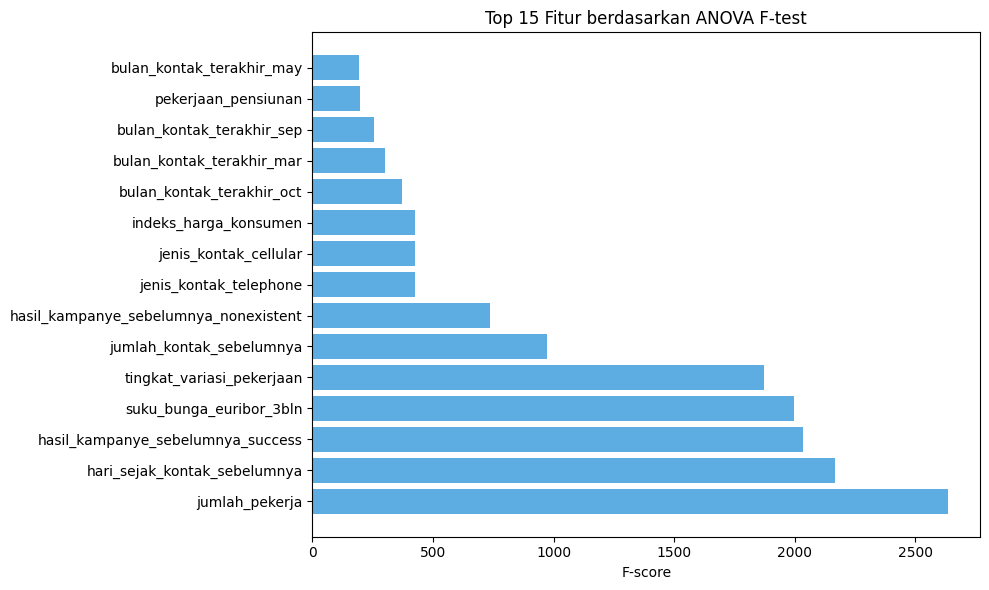


=== Seleksi Top 20 Fitur ===
Fitur terpilih (20 fitur):
  1. hari_sejak_kontak_sebelumnya (F=2165.7577, p=0.00e+00)
  2. jumlah_kontak_sebelumnya (F=972.7922, p=3.93e-208)
  3. tingkat_variasi_pekerjaan (F=1871.8012, p=0.00e+00)
  4. indeks_harga_konsumen (F=424.7408, p=2.59e-93)
  5. suku_bunga_euribor_3bln (F=1995.3844, p=0.00e+00)
  6. jumlah_pekerja (F=2635.6271, p=0.00e+00)
  7. pekerjaan_mahasiswa (F=134.8445, p=4.59e-31)
  8. pekerjaan_pekerja kasar (F=94.5717, p=2.68e-22)
  9. pekerjaan_pensiunan (F=195.1597, p=4.00e-44)
  10. gagal_bayar_sebelumnya_no (F=192.1866, p=1.76e-43)
  11. gagal_bayar_sebelumnya_unknown (F=192.0402, p=1.89e-43)
  12. jenis_kontak_cellular (F=425.8074, p=1.53e-93)
  13. jenis_kontak_telephone (F=425.8074, p=1.53e-93)
  14. bulan_kontak_terakhir_apr (F=103.9850, p=2.37e-24)
  15. bulan_kontak_terakhir_mar (F=298.9427, p=1.88e-66)
  16. bulan_kontak_terakhir_may (F=193.6156, p=8.63e-44)
  17. bulan_kontak_terakhir_oct (F=372.3954, p=3.68e-82)
  18. bula

In [15]:
# Hitung F-score dan p-value untuk SEMUA fitur
from scipy.stats import f

f_selector_full = SelectKBest(score_func=f_classif, k='all')
X_train_f_full = f_selector_full.fit_transform(X_train, y_train)

# Ekstrak F-score dan hitung p-value
f_scores_arr = f_selector_full.scores_
f_pvalues = f_selector_full.pvalues_

# Buat dataframe lengkap
f_results = pd.DataFrame({
    'feature': X_train.columns,
    'f_score': f_scores_arr,
    'p_value': f_pvalues
}).sort_values('f_score', ascending=False)

# Reset index untuk ranking
f_results['rank'] = range(1, len(f_results) + 1)

# Also create f_scores as alias for backwards compatibility in plotting
f_scores = f_results

print('=== ANOVA F-test Results (SEMUA FITUR) ===')
print(f'\nTotal fitur: {len(f_results)}')
print(f'\nStatistik F-score:')
print(f_results['f_score'].describe())
print(f'\nStatistik p-value:')
print(f_results['p_value'].describe())

print('\n=== SEMUA Fitur berdasarkan F-score ===')
display(f_results)

print('\n=== Fitur dengan p-value < 0.05 (Signifikan) ===')
sig_features = f_results[f_results['p_value'] < 0.05]
print(f'Jumlah fitur signifikan (p < 0.05): {len(sig_features)}')
display(sig_features.sort_values('p_value').head(20))

# Visualisasi
plt.figure(figsize=(10, 6))
top_n = 15
plt.barh(range(top_n), f_results.head(top_n)['f_score'][::-1], color='#5dade2')
plt.yticks(range(top_n), f_results.head(top_n)['feature'][::-1])
plt.xlabel('F-score')
plt.title(f'Top {top_n} Fitur berdasarkan ANOVA F-test')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# --- SELEKSI dengan SelectKBest k=20 ---
print('\n=== Seleksi Top 20 Fitur ===')
k_top = 20
f_selector = SelectKBest(score_func=f_classif, k=k_top)
X_train_f = f_selector.fit_transform(X_train, y_train)
X_test_f = f_selector.transform(X_test)
f_features = X_train.columns[f_selector.get_support()]

print(f'Fitur terpilih ({k_top} fitur):')
for i, feat in enumerate(f_features, 1):
    row = f_results[f_results['feature'] == feat].iloc[0]
    print(f'  {i}. {feat} (F={row["f_score"]:.4f}, p={row["p_value"]:.2e})')


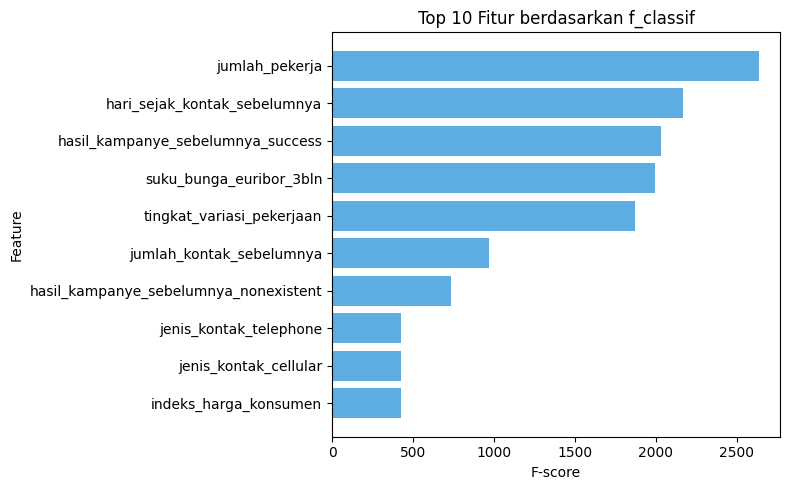

In [16]:
plt.figure(figsize=(8, 5))
plt.barh(f_scores.head(10)['feature'][::-1], f_results.head(10)['f_score'][::-1], color='#5dade2')
plt.title('Top 10 Fitur berdasarkan f_classif')
plt.xlabel('F-score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


In [17]:
f_model = LogisticRegression(max_iter=2000, class_weight='balanced')
f_result = evaluate_model(f_model, X_train_f, X_test_f, y_train, y_test, 'SelectKBest + f_classif', X_train_f.shape[1], f_features)
results.append(f_result)
feature_sets['SelectKBest + f_classif'] = list(f_features)
f_result

# Display result as dataframe
f_df = pd.DataFrame([f_result])
display(f_df[['method', 'n_features', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']])


,method,n_features,accuracy,precision,recall,f1,roc_auc
0,SelectKBest + f_classif,20,0.784031,0.297485,0.655832,0.409308,0.787612


### 5.3 SelectKBest dengan `mutual_info_classif`

Mutual information dapat menangkap dependensi non-linear antara fitur dan target.

**Cocok untuk:**

- fitur numerik
- fitur kategorikal yang sudah di-encoding
- lebih fleksibel dibanding `f_classif` ketika relasi fitur-target tidak sederhana

**Proses:**
1. Estimasi Mutual Information untuk setiap fitur
2. Urutkan berdasarkan MI score
3. Pilih k fitur terbaik

**Catatan:** Mutual Information tidak menghasilkan p-value karena ini adalah estimasi non-parametrik berbasis entropy.

**Output yang akan ditampilkan:**
- Tabel MI score untuk semua fitur
- Visualisasi top features
- Fitur terpilih setelah seleksi


=== Mutual Information Results (SEMUA FITUR) ===

Total fitur: 70

Statistik MI score:
count    70.000000
mean      0.008173
std       0.016941
min       0.000000
25%       0.000000
50%       0.001670
75%       0.006189
max       0.073624
Name: mi_score, dtype: float64

=== SEMUA Fitur berdasarkan Mutual Information ===


,feature,mi_score,rank
7,suku_bunga_euribor_3bln,0.073624,1
5,indeks_harga_konsumen,0.064079,2
6,indeks_kepercayaan_konsumen,0.063498,3
8,jumlah_pekerja,0.063128,4
4,tingkat_variasi_pekerjaan,0.056514,5
...,...,...,...
17,pekerjaan_penyedia jasa,0.000000,66
14,pekerjaan_pemilik bisnis,0.000000,67
12,pekerjaan_manajer,0.000000,68
9,pekerjaan_asisten rumah tangga,0.000000,69


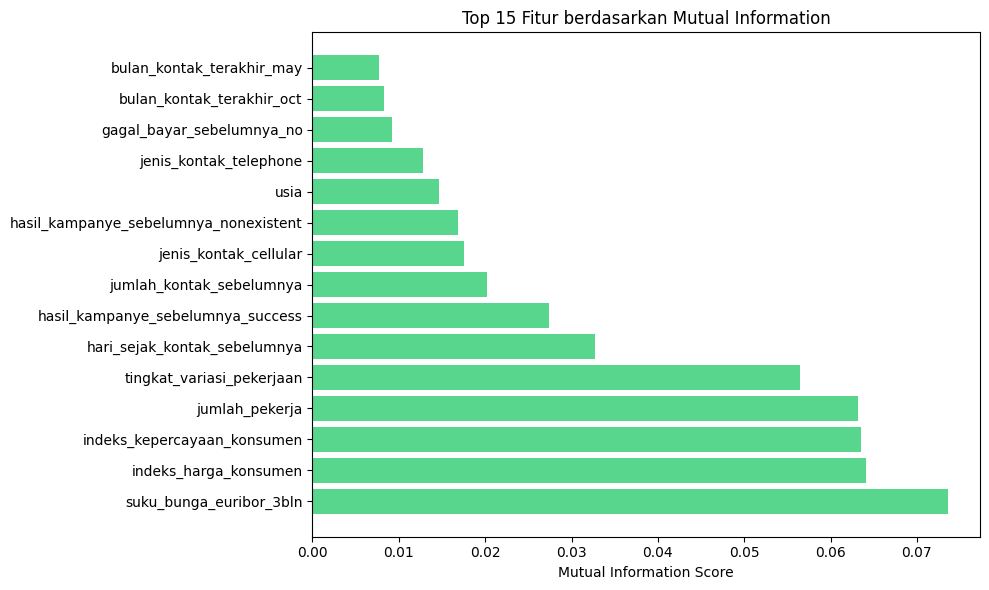


=== Seleksi Top 20 Fitur ===


Fitur terpilih (20 fitur):
  1. usia (MI=0.014674)
  2. hari_sejak_kontak_sebelumnya (MI=0.032677)
  3. jumlah_kontak_sebelumnya (MI=0.020154)
  4. tingkat_variasi_pekerjaan (MI=0.056514)
  5. indeks_harga_konsumen (MI=0.064079)
  6. indeks_kepercayaan_konsumen (MI=0.063498)
  7. suku_bunga_euribor_3bln (MI=0.073624)
  8. jumlah_pekerja (MI=0.063128)
  9. pekerjaan_pensiunan (MI=0.007211)
  10. status_perkawinan_menikah (MI=0.007359)
  11. gagal_bayar_sebelumnya_no (MI=0.009190)
  12. gagal_bayar_sebelumnya_unknown (MI=0.006443)
  13. pinjaman_pribadi_no (MI=0.005428)
  14. jenis_kontak_cellular (MI=0.017507)
  15. jenis_kontak_telephone (MI=0.012783)
  16. bulan_kontak_terakhir_mar (MI=0.002376)
  17. bulan_kontak_terakhir_oct (MI=0.008236)
  18. hari_kontak_terakhir_mon (MI=0.000000)
  19. hasil_kampanye_sebelumnya_nonexistent (MI=0.016858)
  20. hasil_kampanye_sebelumnya_success (MI=0.027386)


In [18]:
# Hitung Mutual Information untuk SEMUA fitur
mi_selector_full = SelectKBest(score_func=mutual_info_classif, k='all')
X_train_mi_full = mi_selector_full.fit_transform(X_train, y_train)

# Ekstrak MI scores
mi_scores_arr = mi_selector_full.scores_

# Buat dataframe lengkap
mi_results = pd.DataFrame({
    'feature': X_train.columns,
    'mi_score': mi_scores_arr
}).sort_values('mi_score', ascending=False)

# Reset index untuk ranking
mi_results['rank'] = range(1, len(mi_results) + 1)

# Also create mi_scores as alias for backwards compatibility
mi_scores = mi_results

print('=== Mutual Information Results (SEMUA FITUR) ===')
print(f'\nTotal fitur: {len(mi_results)}')
print(f'\nStatistik MI score:')
print(mi_results['mi_score'].describe())

print('\n=== SEMUA Fitur berdasarkan Mutual Information ===')
display(mi_results)

# Visualisasi
plt.figure(figsize=(10, 6))
top_n = 15
plt.barh(range(top_n), mi_results.head(top_n)['mi_score'][::-1], color='#58d68d')
plt.yticks(range(top_n), mi_results.head(top_n)['feature'][::-1])
plt.xlabel('Mutual Information Score')
plt.title(f'Top {top_n} Fitur berdasarkan Mutual Information')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# --- SELEKSI dengan SelectKBest k=20 ---
print('\n=== Seleksi Top 20 Fitur ===')
k_top = 20
mi_selector = SelectKBest(score_func=mutual_info_classif, k=k_top)
X_train_mi = mi_selector.fit_transform(X_train, y_train)
X_test_mi = mi_selector.transform(X_test)
mi_features = X_train.columns[mi_selector.get_support()]

print(f'Fitur terpilih ({k_top} fitur):')
for i, feat in enumerate(mi_features, 1):
    row = mi_results[mi_results['feature'] == feat].iloc[0]
    print(f'  {i}. {feat} (MI={row["mi_score"]:.6f})')


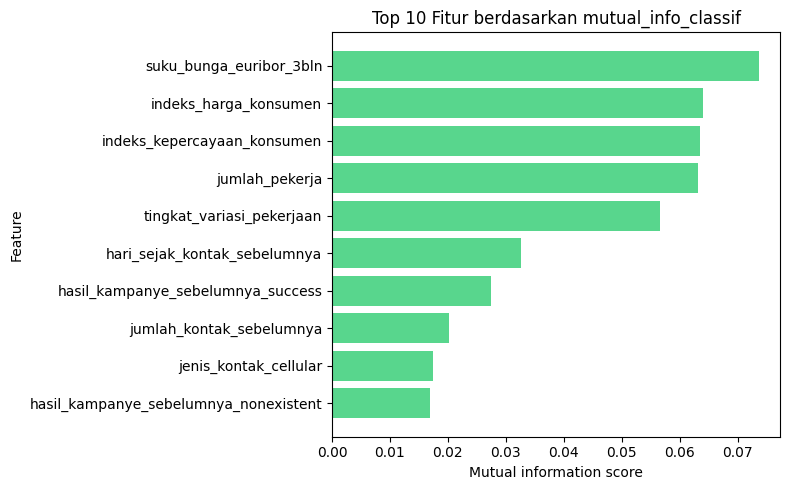

In [19]:
plt.figure(figsize=(8, 5))
plt.barh(mi_results.head(10)['feature'][::-1], mi_results.head(10)['mi_score'][::-1], color='#58d68d')
plt.title('Top 10 Fitur berdasarkan mutual_info_classif')
plt.xlabel('Mutual information score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


In [20]:
mi_model = LogisticRegression(max_iter=2000, class_weight='balanced')
mi_result = evaluate_model(mi_model, X_train_mi, X_test_mi, y_train, y_test, 'SelectKBest + mutual_info', X_train_mi.shape[1], mi_features)
results.append(mi_result)
feature_sets['SelectKBest + mutual_info'] = list(mi_features)
mi_result

# Display result as dataframe
mi_df = pd.DataFrame([mi_result])
display(mi_df[['method', 'n_features', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']])


,method,n_features,accuracy,precision,recall,f1,roc_auc
0,SelectKBest + mutual_info,20,0.781632,0.296075,0.66348,0.40944,0.779516


### 5.4 SelectKBest dengan `chi2`

`chi2` mengharuskan semua fitur bernilai **non-negative**. Karena itu kita perlu men-scale fitur numerik dengan `MinMaxScaler`, lalu menggabungkannya lagi dengan hasil one-hot encoding.

**Cocok untuk:**

- fitur kategorikal yang sudah di-one-hot encode
- data frekuensi dan text features non-negative
- fitur numerik yang sudah dibuat non-negative
- tidak dipakai langsung pada string kategorikal mentah

**Proses:**
1. Hitung Chi-Square statistic dan p-value untuk setiap fitur
2. Urutkan berdasarkan Chi-Square score
3. Pilih fitur dengan p-value < threshold ATAU top-k berdasarkan score

**Syarat:** Semua nilai fitur harus **non-negative**.

**Output yang akan ditampilkan:**
- Tabel Chi-Square score dan p-value untuk semua fitur
- Fitur dengan p-value < 0.05 (signifikan)
- Visualisasi top features
- Fitur terpilih setelah seleksi


In [21]:
# Chi2 memerlukan semua fitur non-negative
# Scale fitur numerik ke [0, 1]
numeric_train = X_train[numeric_columns].copy()
numeric_test = X_test[numeric_columns].copy()

scaler = MinMaxScaler()
numeric_train_scaled = pd.DataFrame(
    scaler.fit_transform(numeric_train),
    columns=numeric_columns,
    index=X_train.index
)
numeric_test_scaled = pd.DataFrame(
    scaler.transform(numeric_test),
    columns=numeric_columns,
    index=X_test.index
)

# Gabungkan dengan fitur non-numerik (sudah one-hot, jadi non-negative)
non_numeric_columns = [col for col in X_train.columns if col not in numeric_columns]
X_train_nonneg = pd.concat([numeric_train_scaled, X_train[non_numeric_columns]], axis=1)
X_test_nonneg = pd.concat([numeric_test_scaled, X_test[non_numeric_columns]], axis=1)

# Verifikasi semua nilai non-negative
print('Range nilai setelah scaling:')
print(f'Min: {X_train_nonneg.min().min():.4f}')
print(f'Max: {X_train_nonneg.max().max():.4f}')
assert X_train_nonneg.min().min() >= 0, 'Ada nilai negatif!'


Range nilai setelah scaling:
Min: 0.0000
Max: 1.0000


=== Chi-Square Test Results (SEMUA FITUR) ===

Total fitur: 70

Statistik Chi-Square score:
count      70.000000
mean       79.163212
std       226.075850
min         0.000776
25%         0.268409
50%         4.547643
75%        71.741078
max      1769.658471
Name: chi2_score, dtype: float64

Statistik p-value:
count    7.000000e+01
mean     2.604056e-01
std      3.428005e-01
min      0.000000e+00
25%      3.239999e-17
50%      3.341669e-02
75%      6.059199e-01
max      9.777767e-01
Name: p_value, dtype: float64

=== SEMUA Fitur berdasarkan Chi-Square ===


,feature,chi2_score,p_value,rank
61,hasil_kampanye_sebelumnya_success,1769.658471,0.000000e+00,1
7,suku_bunga_euribor_3bln,413.241774,7.219087e-92,2
52,bulan_kontak_terakhir_oct,358.230348,6.837908e-80,3
49,bulan_kontak_terakhir_mar,290.342319,4.187630e-65,4
43,jenis_kontak_telephone,263.487484,2.980898e-59,5
...,...,...,...,...
63,pulau_Jawa,0.017651,8.943058e-01,66
45,bulan_kontak_terakhir_aug,0.008735,9.255364e-01,67
39,pinjaman_pribadi_no,0.006750,9.345206e-01,68
41,pinjaman_pribadi_yes,0.001767,9.664666e-01,69



=== Fitur dengan p-value < 0.05 (Signifikan) ===
Jumlah fitur signifikan (p < 0.05): 36


,feature,chi2_score,p_value,rank
61,hasil_kampanye_sebelumnya_success,1769.658471,0.000000e+00,1
7,suku_bunga_euribor_3bln,413.241774,7.219087e-92,2
52,bulan_kontak_terakhir_oct,358.230348,6.837908e-80,3
49,bulan_kontak_terakhir_mar,290.342319,4.187630e-65,4
43,jenis_kontak_telephone,263.487484,2.980898e-59,5
4,tingkat_variasi_pekerjaan,253.846950,3.765260e-57,6
53,bulan_kontak_terakhir_sep,246.160160,1.784781e-55,7
8,jumlah_pekerja,225.716636,5.122835e-51,8
3,jumlah_kontak_sebelumnya,216.134531,6.303391e-49,9
16,pekerjaan_pensiunan,185.002446,3.919801e-42,10



=== Fitur dengan p-value < 0.01 (Sangat Signifikan) ===
Jumlah fitur sangat signifikan (p < 0.01): 32


,feature,chi2_score,p_value,rank
61,hasil_kampanye_sebelumnya_success,1769.658471,0.000000e+00,1
7,suku_bunga_euribor_3bln,413.241774,7.219087e-92,2
52,bulan_kontak_terakhir_oct,358.230348,6.837908e-80,3
49,bulan_kontak_terakhir_mar,290.342319,4.187630e-65,4
43,jenis_kontak_telephone,263.487484,2.980898e-59,5
4,tingkat_variasi_pekerjaan,253.846950,3.765260e-57,6
53,bulan_kontak_terakhir_sep,246.160160,1.784781e-55,7
8,jumlah_pekerja,225.716636,5.122835e-51,8
3,jumlah_kontak_sebelumnya,216.134531,6.303391e-49,9
16,pekerjaan_pensiunan,185.002446,3.919801e-42,10


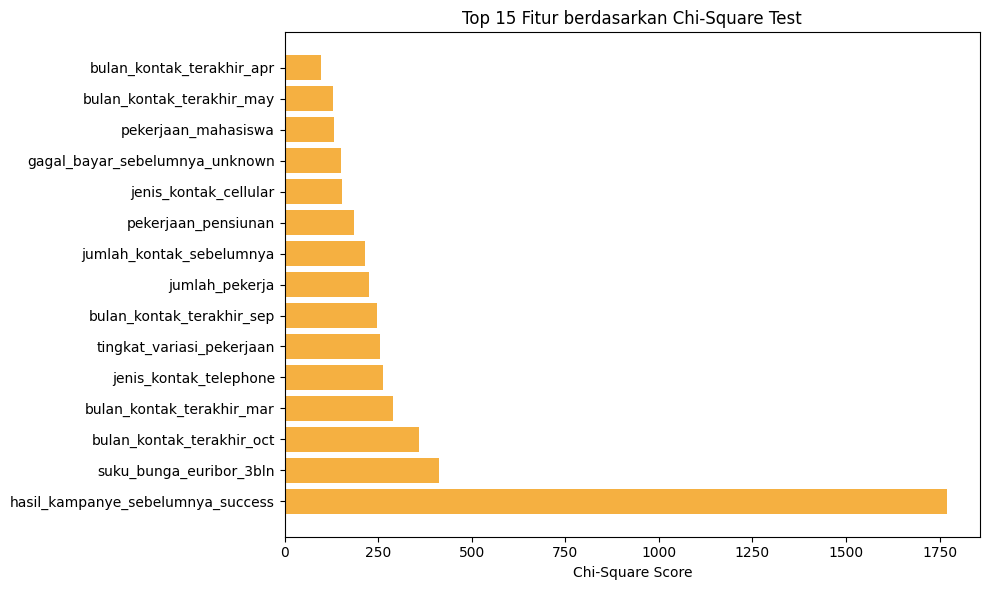


=== Seleksi Top 20 Fitur ===
Fitur terpilih (20 fitur):
  1. hari_sejak_kontak_sebelumnya (χ²=69.4111, p=7.99e-17)
  2. jumlah_kontak_sebelumnya (χ²=216.1345, p=6.30e-49)
  3. tingkat_variasi_pekerjaan (χ²=253.8469, p=3.77e-57)
  4. indeks_harga_konsumen (χ²=39.6490, p=3.04e-10)
  5. suku_bunga_euribor_3bln (χ²=413.2418, p=7.22e-92)
  6. jumlah_pekerja (χ²=225.7166, p=5.12e-51)
  7. pekerjaan_mahasiswa (χ²=130.8948, p=2.61e-30)
  8. pekerjaan_pekerja kasar (χ²=72.5177, p=1.66e-17)
  9. pekerjaan_pensiunan (χ²=185.0024, p=3.92e-42)
  10. gagal_bayar_sebelumnya_unknown (χ²=150.8884, p=1.11e-34)
  11. jenis_kontak_cellular (χ²=152.6983, p=4.46e-35)
  12. jenis_kontak_telephone (χ²=263.4875, p=2.98e-59)
  13. bulan_kontak_terakhir_apr (χ²=96.5729, p=8.60e-23)
  14. bulan_kontak_terakhir_dec (χ²=87.4923, p=8.46e-21)
  15. bulan_kontak_terakhir_mar (χ²=290.3423, p=4.19e-65)
  16. bulan_kontak_terakhir_may (χ²=128.0624, p=1.09e-29)
  17. bulan_kontak_terakhir_oct (χ²=358.2303, p=6.84e-80)
  

In [22]:
# Hitung Chi-Square dan p-value untuk SEMUA fitur
from scipy.stats import chi2 as chi2_dist

chi2_selector_full = SelectKBest(score_func=chi2, k='all')
X_train_chi2_full = chi2_selector_full.fit_transform(X_train_nonneg, y_train)

# Ekstrak Chi2 scores dan p-values
chi2_scores_arr = chi2_selector_full.scores_
chi2_pvalues = chi2_selector_full.pvalues_

# Buat dataframe lengkap
chi2_results = pd.DataFrame({
    'feature': X_train_nonneg.columns,
    'chi2_score': chi2_scores_arr,
    'p_value': chi2_pvalues
}).sort_values('chi2_score', ascending=False)

# Reset index untuk ranking
chi2_results['rank'] = range(1, len(chi2_results) + 1)

# Also create chi2_scores as alias
chi2_scores = chi2_results

print('=== Chi-Square Test Results (SEMUA FITUR) ===')
print(f'\nTotal fitur: {len(chi2_results)}')
print(f'\nStatistik Chi-Square score:')
print(chi2_results['chi2_score'].describe())
print(f'\nStatistik p-value:')
print(chi2_results['p_value'].describe())

print('\n=== SEMUA Fitur berdasarkan Chi-Square ===')
display(chi2_results)

print('\n=== Fitur dengan p-value < 0.05 (Signifikan) ===')
sig_chi2 = chi2_results[chi2_results['p_value'] < 0.05]
print(f'Jumlah fitur signifikan (p < 0.05): {len(sig_chi2)}')
display(sig_chi2.sort_values('p_value').head(20))

print('\n=== Fitur dengan p-value < 0.01 (Sangat Signifikan) ===')
sig_chi2_strict = chi2_results[chi2_results['p_value'] < 0.01]
print(f'Jumlah fitur sangat signifikan (p < 0.01): {len(sig_chi2_strict)}')
display(sig_chi2_strict.sort_values('p_value').head(20))

# Visualisasi
plt.figure(figsize=(10, 6))
top_n = 15
plt.barh(range(top_n), chi2_results.head(top_n)['chi2_score'][::-1], color='#f5b041')
plt.yticks(range(top_n), chi2_results.head(top_n)['feature'][::-1])
plt.xlabel('Chi-Square Score')
plt.title(f'Top {top_n} Fitur berdasarkan Chi-Square Test')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# --- SELEKSI dengan SelectKBest k=20 ---
print('\n=== Seleksi Top 20 Fitur ===')
k_top = 20
chi2_selector = SelectKBest(score_func=chi2, k=k_top)
X_train_chi2 = chi2_selector.fit_transform(X_train_nonneg, y_train)
X_test_chi2 = chi2_selector.transform(X_test_nonneg)
chi2_features = X_train_nonneg.columns[chi2_selector.get_support()]

print(f'Fitur terpilih ({k_top} fitur):')
for i, feat in enumerate(chi2_features, 1):
    row = chi2_results[chi2_results['feature'] == feat].iloc[0]
    print(f'  {i}. {feat} (χ²={row["chi2_score"]:.4f}, p={row["p_value"]:.2e})')

# --- SELEKSI ALTERNATIF dengan p-value threshold ---
print('\n=== Alternatif: Seleksi dengan p-value < 0.05 ===')
pval_threshold = 0.05
selected_by_pval = chi2_results[chi2_results['p_value'] < pval_threshold]['feature'].tolist()
print(f'Jumlah fitur dengan p < {pval_threshold}: {len(selected_by_pval)}')
if len(selected_by_pval) > 0:
    print('Fitur terpilih:')
    for i, feat in enumerate(selected_by_pval[:20], 1):
        row = chi2_results[chi2_results['feature'] == feat].iloc[0]
        print(f'  {i}. {feat} (p={row["p_value"]:.2e})')
    if len(selected_by_pval) > 20:
        print(f'  ... dan {len(selected_by_pval) - 20} fitur lainnya')


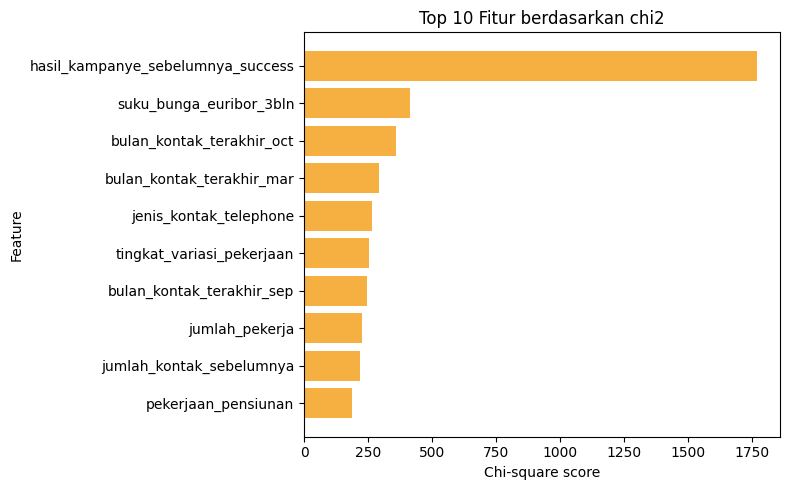

In [23]:
plt.figure(figsize=(8, 5))
plt.barh(chi2_results.head(10)['feature'][::-1], chi2_results.head(10)['chi2_score'][::-1], color='#f5b041')
plt.title('Top 10 Fitur berdasarkan chi2')
plt.xlabel('Chi-square score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


In [24]:
chi2_model = LogisticRegression(max_iter=2000, class_weight='balanced')
chi2_result = evaluate_model(chi2_model, X_train_chi2, X_test_chi2, y_train, y_test, 'SelectKBest + chi2', X_train_chi2.shape[1], chi2_features)
results.append(chi2_result)
feature_sets['SelectKBest + chi2'] = list(chi2_features)
chi2_result

# Display result as dataframe
chi2_df = pd.DataFrame([chi2_result])
display(chi2_df[['method', 'n_features', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']])


,method,n_features,accuracy,precision,recall,f1,roc_auc
0,SelectKBest + chi2,20,0.774433,0.287614,0.661568,0.400927,0.787878


### 5.5 SelectPercentile

Alih-alih memilih jumlah fitur absolut, kita bisa memilih persentase fitur terbaik.

**Cocok untuk:**

- tipe fitur yang sama dengan score function yang dipakai
- sangat praktis untuk fitur hasil encoding yang jumlahnya cukup banyak

**Proses:**
1. Hitung score (F-score dalam kasus ini) untuk semua fitur
2. Urutkan berdasarkan score
3. Pilih top p% fitur

**Perbedaan dengan SelectKBest:**
- SelectKBest: pilih k fitur (angka absolut)
- SelectPercentile: pilih p% fitur (relatif terhadap jumlah fitur)

**Output yang akan ditampilkan:**
- Fitur terpilih berdasarkan percentile


In [25]:
# Gunakan F-score dari perhitungan sebelumnya
# SelectPercentile memilih top 20% fitur

percentile = 20
percentile_selector = SelectPercentile(score_func=f_classif, percentile=percentile)
X_train_pct = percentile_selector.fit_transform(X_train, y_train)
X_test_pct = percentile_selector.transform(X_test)
pct_features = X_train.columns[percentile_selector.get_support()]

# Hitung berapa fitur yang terpilih
n_selected = len(pct_features)
n_total = len(X_train.columns)
actual_pct = (n_selected / n_total) * 100

print(f'=== SelectPercentile Results ===')
print(f'Total fitur awal: {n_total}')
print(f'Percentile target: {percentile}%')
print(f'Fitur terpilih: {n_selected}')
print(f'Persentase aktual: {actual_pct:.1f}%')

print(f'\nFitur terpilih ({n_selected} fitur):')
# Tampilkan dengan F-score dari hasil sebelumnya
for j, feat in enumerate(pct_features, 1):
    row = f_results[f_results['feature'] == feat].iloc[0] if feat in f_results['feature'].values else None
    if row is not None:
        print(f'  {j}. {feat} (F={row["f_score"]:.4f}, p={row["p_value"]:.2e})')
    else:
        print(f'  {j}. {feat}')

pct_model = LogisticRegression(max_iter=2000, class_weight='balanced')
pct_result = evaluate_model(pct_model, X_train_pct, X_test_pct, y_train, y_test, 'SelectPercentile + f_classif', X_train_pct.shape[1], pct_features)
results.append(pct_result)
feature_sets['SelectPercentile + f_classif'] = list(pct_features)
pct_result

# Display result as dataframe
pct_df = pd.DataFrame([pct_result])
display(pct_df[['method', 'n_features', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']])


=== SelectPercentile Results ===
Total fitur awal: 70
Percentile target: 20%
Fitur terpilih: 14
Persentase aktual: 20.0%

Fitur terpilih (14 fitur):
  1. hari_sejak_kontak_sebelumnya (F=2165.7577, p=0.00e+00)
  2. jumlah_kontak_sebelumnya (F=972.7922, p=3.93e-208)
  3. tingkat_variasi_pekerjaan (F=1871.8012, p=0.00e+00)
  4. indeks_harga_konsumen (F=424.7408, p=2.59e-93)
  5. suku_bunga_euribor_3bln (F=1995.3844, p=0.00e+00)
  6. jumlah_pekerja (F=2635.6271, p=0.00e+00)
  7. pekerjaan_pensiunan (F=195.1597, p=4.00e-44)
  8. jenis_kontak_cellular (F=425.8074, p=1.53e-93)
  9. jenis_kontak_telephone (F=425.8074, p=1.53e-93)
  10. bulan_kontak_terakhir_mar (F=298.9427, p=1.88e-66)
  11. bulan_kontak_terakhir_oct (F=372.3954, p=3.68e-82)
  12. bulan_kontak_terakhir_sep (F=253.0654, p=1.33e-56)
  13. hasil_kampanye_sebelumnya_nonexistent (F=736.1899, p=5.52e-159)
  14. hasil_kampanye_sebelumnya_success (F=2032.1480, p=0.00e+00)


,method,n_features,accuracy,precision,recall,f1,roc_auc
0,SelectPercentile + f_classif,14,0.776178,0.290939,0.669216,0.405562,0.779887


### 5.6 GenericUnivariateSelect

Metode ini memberi antarmuka yang lebih fleksibel untuk memilih strategi univariat. Di sini kita pakai mode `k_best` sebagai ilustrasi.

**Cocok untuk:**

- fitur numerik atau hasil encoding
- tetap mengikuti score function yang dipilih di dalam selector

**Proses:**
1. Hitung score menggunakan fungsi scoring yang dipilih
2. Gunakan parameter selection mode (k_best, percentile, fpr, fdr, fwe)
3. Pilih fitur berdasarkan mode dan parameter

**Mode yang tersedia:**
- `k_best`: pilih k fitur terbaik (seperti SelectKBest)
- `percentile`: pilih p% fitur terbaik (seperti SelectPercentile)
- `fpr`: pilih fitur dengan p-value < false positive rate threshold
- `fdr`: pilih fitur dengan p-value < false discovery rate threshold
- `fwe`: pilih fitur dengan p-value < family-wise error rate threshold

**Output yang akan ditampilkan:**
- Fitur terpilih berdasarkan mode selection


In [26]:
# GenericUnivariateSelect dengan mode k_best
# Mode lain yang bisa dicoba: 'percentile', 'fpr', 'fdr', 'fwe'

mode = 'k_best'
param = 15  # jumlah fitur untuk k_best

gus_selector = GenericUnivariateSelect(score_func=f_classif, mode=mode, param=param)
X_train_gus = gus_selector.fit_transform(X_train, y_train)
X_test_gus = gus_selector.transform(X_test)
gus_features = X_train.columns[gus_selector.get_support()]

print(f'=== GenericUnivariateSelect Results ===')
print(f'Mode: {mode}')
print(f'Parameter: {param}')
print(f'Total fitur awal: {len(X_train.columns)}')
print(f'Fitur terpilih: {len(gus_features)}')

print(f'\nFitur terpilih:')
for j, feat in enumerate(gus_features, 1):
    row = f_results[f_results['feature'] == feat].iloc[0] if feat in f_results['feature'].values else None
    if row is not None:
        print(f'  {j}. {feat} (F={row["f_score"]:.4f}, p={row["p_value"]:.2e})')
    else:
        print(f'  {j}. {feat}')

gus_model = LogisticRegression(max_iter=2000, class_weight='balanced')
gus_result = evaluate_model(gus_model, X_train_gus, X_test_gus, y_train, y_test, 'GenericUnivariateSelect', X_train_gus.shape[1], gus_features)
results.append(gus_result)
feature_sets['GenericUnivariateSelect'] = list(gus_features)
gus_result

# Display result as dataframe
gus_df = pd.DataFrame([gus_result])
display(gus_df[['method', 'n_features', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']])


=== GenericUnivariateSelect Results ===
Mode: k_best
Parameter: 15
Total fitur awal: 70
Fitur terpilih: 15

Fitur terpilih:
  1. hari_sejak_kontak_sebelumnya (F=2165.7577, p=0.00e+00)
  2. jumlah_kontak_sebelumnya (F=972.7922, p=3.93e-208)
  3. tingkat_variasi_pekerjaan (F=1871.8012, p=0.00e+00)
  4. indeks_harga_konsumen (F=424.7408, p=2.59e-93)
  5. suku_bunga_euribor_3bln (F=1995.3844, p=0.00e+00)
  6. jumlah_pekerja (F=2635.6271, p=0.00e+00)
  7. pekerjaan_pensiunan (F=195.1597, p=4.00e-44)
  8. jenis_kontak_cellular (F=425.8074, p=1.53e-93)
  9. jenis_kontak_telephone (F=425.8074, p=1.53e-93)
  10. bulan_kontak_terakhir_mar (F=298.9427, p=1.88e-66)
  11. bulan_kontak_terakhir_may (F=193.6156, p=8.63e-44)
  12. bulan_kontak_terakhir_oct (F=372.3954, p=3.68e-82)
  13. bulan_kontak_terakhir_sep (F=253.0654, p=1.33e-56)
  14. hasil_kampanye_sebelumnya_nonexistent (F=736.1899, p=5.52e-159)
  15. hasil_kampanye_sebelumnya_success (F=2032.1480, p=0.00e+00)


,method,n_features,accuracy,precision,recall,f1,roc_auc
0,GenericUnivariateSelect,15,0.761562,0.277344,0.678776,0.393788,0.787053


### Perbandingan awal hasil filter methods


In [27]:
filter_results = pd.DataFrame(results)
filter_results[['method', 'n_features', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']].sort_values('f1', ascending=False)


,method,n_features,accuracy,precision,recall,f1,roc_auc
1,VarianceThreshold,68,0.812609,0.335938,0.657744,0.444732,0.788598
0,Baseline (all features),70,0.810864,0.333010,0.655832,0.441726,0.788668
3,SelectKBest + mutual_info,20,0.781632,0.296075,0.663480,0.409440,0.779516
2,SelectKBest + f_classif,20,0.784031,0.297485,0.655832,0.409308,0.787612
5,SelectPercentile + f_classif,14,0.776178,0.290939,0.669216,0.405562,0.779887
4,SelectKBest + chi2,20,0.774433,0.287614,0.661568,0.400927,0.787878
6,GenericUnivariateSelect,15,0.761562,0.277344,0.678776,0.393788,0.787053


### Visualisasi Korelasi Fitur Terpilih

Untuk memahami hubungan antar fitur yang dipilih oleh berbagai metode, kita akan melihat korelasi antar fitur top.


Fitur yang dipilih oleh >= 2 metode filter: 26

Top 10 fitur paling sering terpilih:
  - hari_sejak_kontak_sebelumnya: 6 metode
  - jumlah_kontak_sebelumnya: 6 metode
  - tingkat_variasi_pekerjaan: 6 metode
  - indeks_harga_konsumen: 6 metode
  - suku_bunga_euribor_3bln: 6 metode
  - jumlah_pekerja: 6 metode
  - pekerjaan_pensiunan: 6 metode
  - jenis_kontak_cellular: 6 metode
  - jenis_kontak_telephone: 6 metode
  - bulan_kontak_terakhir_mar: 6 metode


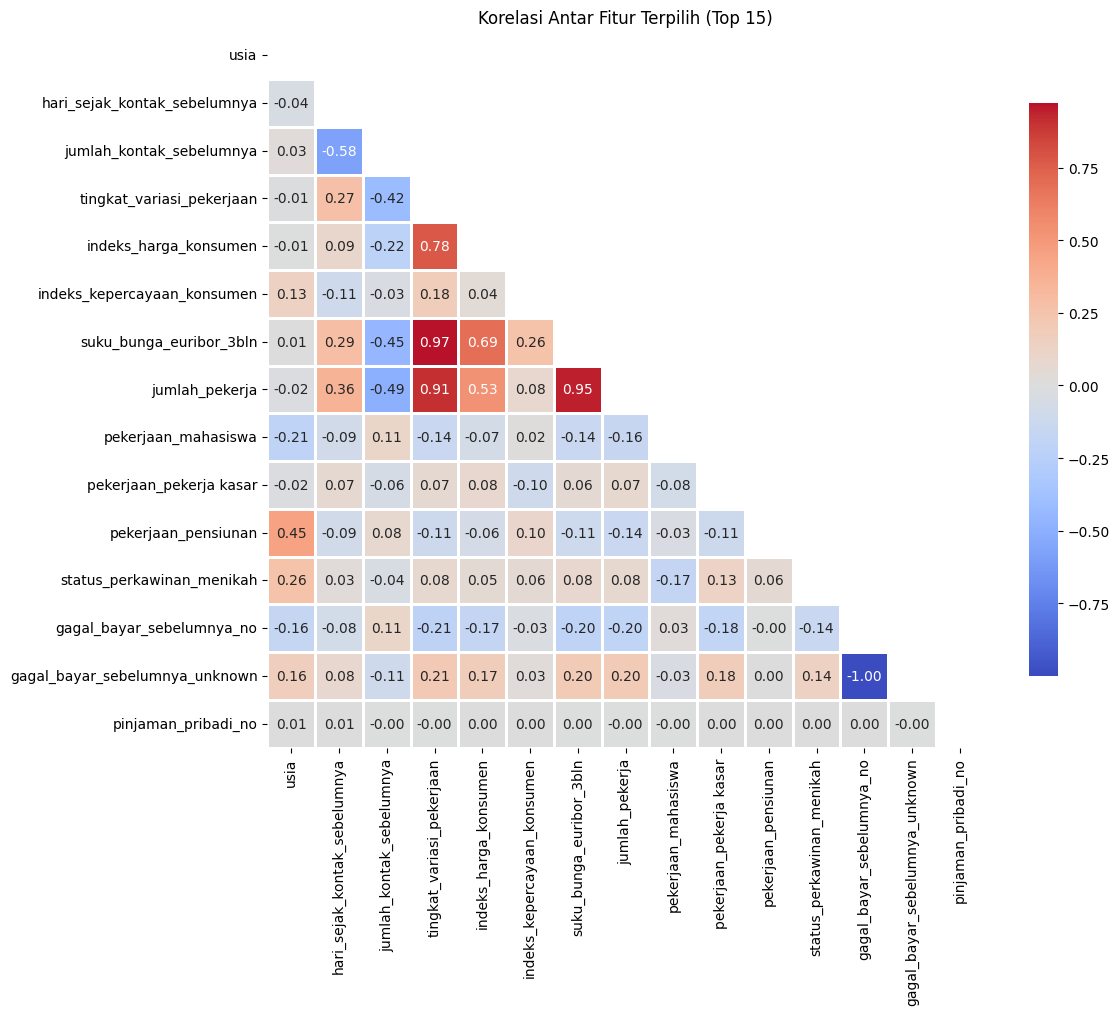


Interpretasi:
- Warna merah: korelasi positif (fitur bergerak searah)
- Warna biru: korelasi negatif (fitur bergerak berlawanan)
- Korelasi tinggi (>0.7 atau <-0.7) menunjukkan redundansi
- Fitur yang sangat berkorelasi mungkin tidak perlu keduanya


In [28]:
# Analisis korelasi untuk fitur-fitur yang sering terpilih
# Kumpulkan fitur yang dipilih oleh minimal 2 metode

from collections import Counter

all_selected = []
for method, features in feature_sets.items():
    if 'filter' in method.lower() or 'variance' in method.lower() or 'select' in method.lower() or 'percentile' in method.lower() or 'generic' in method.lower() or 'chi2' in method.lower() or 'mutual' in method.lower():
        all_selected.extend(features)

feature_counts = Counter(all_selected)
frequent_features = [feat for feat, count in feature_counts.items() if count >= 2]

print(f'Fitur yang dipilih oleh >= 2 metode filter: {len(frequent_features)}')
print(f'\nTop 10 fitur paling sering terpilih:')
for feat, count in feature_counts.most_common(10):
    print(f'  - {feat}: {count} metode')

# Plot korelasi heatmap untuk top fitur
if len(frequent_features) > 1:
    top_corr_features = frequent_features[:15]  # Ambil top 15 untuk korelasi
    
    # Ambil data untuk fitur-fitur ini
    corr_data = X_train[top_corr_features].copy()
    
    # Hitung korelasi
    corr_matrix = corr_data.corr()
    
    # Plot heatmap
    plt.figure(figsize=(12, 10))
    import seaborn as sns
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
                center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title('Korelasi Antar Fitur Terpilih (Top 15)')
    plt.tight_layout()
    plt.show()
    
    print('\nInterpretasi:')
    print('- Warna merah: korelasi positif (fitur bergerak searah)')
    print('- Warna biru: korelasi negatif (fitur bergerak berlawanan)')
    print('- Korelasi tinggi (>0.7 atau <-0.7) menunjukkan redundansi')
    print('- Fitur yang sangat berkorelasi mungkin tidak perlu keduanya')


## 6. Wrapper Methods

Pada bagian ini, subset fitur dievaluasi melalui model klasifikasi. Karena wrapper methods lebih mahal secara komputasi, kita mulai dari kandidat fitur yang sudah diperkecil menggunakan ranking `f_classif`.


In [29]:
wrapper_pool_size = 15
wrapper_pool = f_scores.head(wrapper_pool_size)['feature'].tolist()

X_train_wrapper = X_train[wrapper_pool].copy()
X_test_wrapper = X_test[wrapper_pool].copy()

print('Wrapper pool size:', len(wrapper_pool))
print(wrapper_pool)


Wrapper pool size: 15
['jumlah_pekerja', 'hari_sejak_kontak_sebelumnya', 'hasil_kampanye_sebelumnya_success', 'suku_bunga_euribor_3bln', 'tingkat_variasi_pekerjaan', 'jumlah_kontak_sebelumnya', 'hasil_kampanye_sebelumnya_nonexistent', 'jenis_kontak_telephone', 'jenis_kontak_cellular', 'indeks_harga_konsumen', 'bulan_kontak_terakhir_oct', 'bulan_kontak_terakhir_mar', 'bulan_kontak_terakhir_sep', 'pekerjaan_pensiunan', 'bulan_kontak_terakhir_may']


### 6.1 Sequential Forward Selection

**Cocok untuk:** fitur numerik dan fitur kategorikal yang sudah di-encoding ke numerik. Tidak dipakai langsung pada string mentah.


In [30]:
wrapper_model = LogisticRegression(max_iter=2000, class_weight='balanced')

sfs_forward = SequentialFeatureSelector(
    wrapper_model,
    n_features_to_select=8,
    direction='forward',
    scoring='f1',
    cv=5,
    n_jobs=-1
)

X_train_sfs_f = sfs_forward.fit_transform(X_train_wrapper, y_train)
X_test_sfs_f = sfs_forward.transform(X_test_wrapper)
sfs_forward_features = X_train_wrapper.columns[sfs_forward.get_support()]

sfs_forward_result = evaluate_model(
    LogisticRegression(max_iter=2000, class_weight='balanced'),
    X_train_sfs_f, X_test_sfs_f, y_train, y_test,
    'SFS Forward', X_train_sfs_f.shape[1], sfs_forward_features
)

results.append(sfs_forward_result)
feature_sets['SFS Forward'] = list(sfs_forward_features)
sfs_forward_result

# Display result as dataframe
sfs_f_df = pd.DataFrame([sfs_forward_result])
display(sfs_f_df[['method', 'n_features', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']])


,method,n_features,accuracy,precision,recall,f1,roc_auc
0,SFS Forward,8,0.838787,0.375576,0.623327,0.468728,0.781627


### 6.2 Sequential Backward Selection

**Cocok untuk:** fitur numerik dan fitur kategorikal yang sudah di-encoding ke numerik. Tidak dipakai langsung pada string mentah.


In [31]:
sfs_backward = SequentialFeatureSelector(
    wrapper_model,
    n_features_to_select=8,
    direction='backward',
    scoring='f1',
    cv=5,
    n_jobs=-1
)

X_train_sfs_b = sfs_backward.fit_transform(X_train_wrapper, y_train)
X_test_sfs_b = sfs_backward.transform(X_test_wrapper)
sfs_backward_features = X_train_wrapper.columns[sfs_backward.get_support()]

sfs_backward_result = evaluate_model(
    LogisticRegression(max_iter=2000, class_weight='balanced'),
    X_train_sfs_b, X_test_sfs_b, y_train, y_test,
    'SFS Backward', X_train_sfs_b.shape[1], sfs_backward_features
)

results.append(sfs_backward_result)
feature_sets['SFS Backward'] = list(sfs_backward_features)
sfs_backward_result

# Display result as dataframe
sfs_b_df = pd.DataFrame([sfs_backward_result])
display(sfs_b_df[['method', 'n_features', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']])


,method,n_features,accuracy,precision,recall,f1,roc_auc
0,SFS Backward,8,0.844459,0.386091,0.615679,0.474576,0.784107


### 6.3 Recursive Feature Elimination (RFE)

RFE menggunakan model untuk membuang fitur terlemah secara bertahap.

**Cocok untuk:** fitur numerik dan fitur hasil encoding, selama estimator yang dipakai memang menerima input numerik.


In [32]:
rfe_selector = RFE(
    estimator=LogisticRegression(max_iter=2000, class_weight='balanced'),
    n_features_to_select=8,
    step=1
)

X_train_rfe = rfe_selector.fit_transform(X_train_wrapper, y_train)
X_test_rfe = rfe_selector.transform(X_test_wrapper)
rfe_features = X_train_wrapper.columns[rfe_selector.get_support()]

rfe_ranking = pd.DataFrame({
    'feature': X_train_wrapper.columns,
    'ranking': rfe_selector.ranking_
}).sort_values(['ranking', 'feature'])

rfe_ranking


,feature,ranking
11,bulan_kontak_terakhir_mar,1
14,bulan_kontak_terakhir_may,1
10,bulan_kontak_terakhir_oct,1
6,hasil_kampanye_sebelumnya_nonexistent,1
2,hasil_kampanye_sebelumnya_success,1
9,indeks_harga_konsumen,1
7,jenis_kontak_telephone,1
4,tingkat_variasi_pekerjaan,1
13,pekerjaan_pensiunan,2
12,bulan_kontak_terakhir_sep,3


In [33]:
rfe_result = evaluate_model(
    LogisticRegression(max_iter=2000, class_weight='balanced'),
    X_train_rfe, X_test_rfe, y_train, y_test,
    'RFE', X_train_rfe.shape[1], rfe_features
)

results.append(rfe_result)
feature_sets['RFE'] = list(rfe_features)
rfe_result

# Display result as dataframe
rfe_df = pd.DataFrame([rfe_result])
display(rfe_df[['method', 'n_features', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']])


,method,n_features,accuracy,precision,recall,f1,roc_auc
0,RFE,8,0.762653,0.279813,0.686424,0.397564,0.788201


### Perbandingan hasil wrapper methods


In [34]:
wrapper_results = pd.DataFrame(results)
wrapper_results[['method', 'n_features', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']].sort_values('f1', ascending=False)


,method,n_features,accuracy,precision,recall,f1,roc_auc
8,SFS Backward,8,0.844459,0.386091,0.615679,0.474576,0.784107
7,SFS Forward,8,0.838787,0.375576,0.623327,0.468728,0.781627
1,VarianceThreshold,68,0.812609,0.335938,0.657744,0.444732,0.788598
0,Baseline (all features),70,0.810864,0.333010,0.655832,0.441726,0.788668
3,SelectKBest + mutual_info,20,0.781632,0.296075,0.663480,0.409440,0.779516
2,SelectKBest + f_classif,20,0.784031,0.297485,0.655832,0.409308,0.787612
5,SelectPercentile + f_classif,14,0.776178,0.290939,0.669216,0.405562,0.779887
4,SelectKBest + chi2,20,0.774433,0.287614,0.661568,0.400927,0.787878
9,RFE,8,0.762653,0.279813,0.686424,0.397564,0.788201
6,GenericUnivariateSelect,15,0.761562,0.277344,0.678776,0.393788,0.787053


## 7. Ringkasan Hasil

Di bawah ini kita gabungkan semua hasil agar bisa dibandingkan secara langsung.


In [35]:
results_df = pd.DataFrame(results)
summary_df = results_df[['method', 'n_features', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']].sort_values(['f1', 'accuracy'], ascending=False).reset_index(drop=True)
summary_df


,method,n_features,accuracy,precision,recall,f1,roc_auc
0,SFS Backward,8,0.844459,0.386091,0.615679,0.474576,0.784107
1,SFS Forward,8,0.838787,0.375576,0.623327,0.468728,0.781627
2,VarianceThreshold,68,0.812609,0.335938,0.657744,0.444732,0.788598
3,Baseline (all features),70,0.810864,0.333010,0.655832,0.441726,0.788668
4,SelectKBest + mutual_info,20,0.781632,0.296075,0.663480,0.409440,0.779516
5,SelectKBest + f_classif,20,0.784031,0.297485,0.655832,0.409308,0.787612
6,SelectPercentile + f_classif,14,0.776178,0.290939,0.669216,0.405562,0.779887
7,SelectKBest + chi2,20,0.774433,0.287614,0.661568,0.400927,0.787878
8,RFE,8,0.762653,0.279813,0.686424,0.397564,0.788201
9,GenericUnivariateSelect,15,0.761562,0.277344,0.678776,0.393788,0.787053


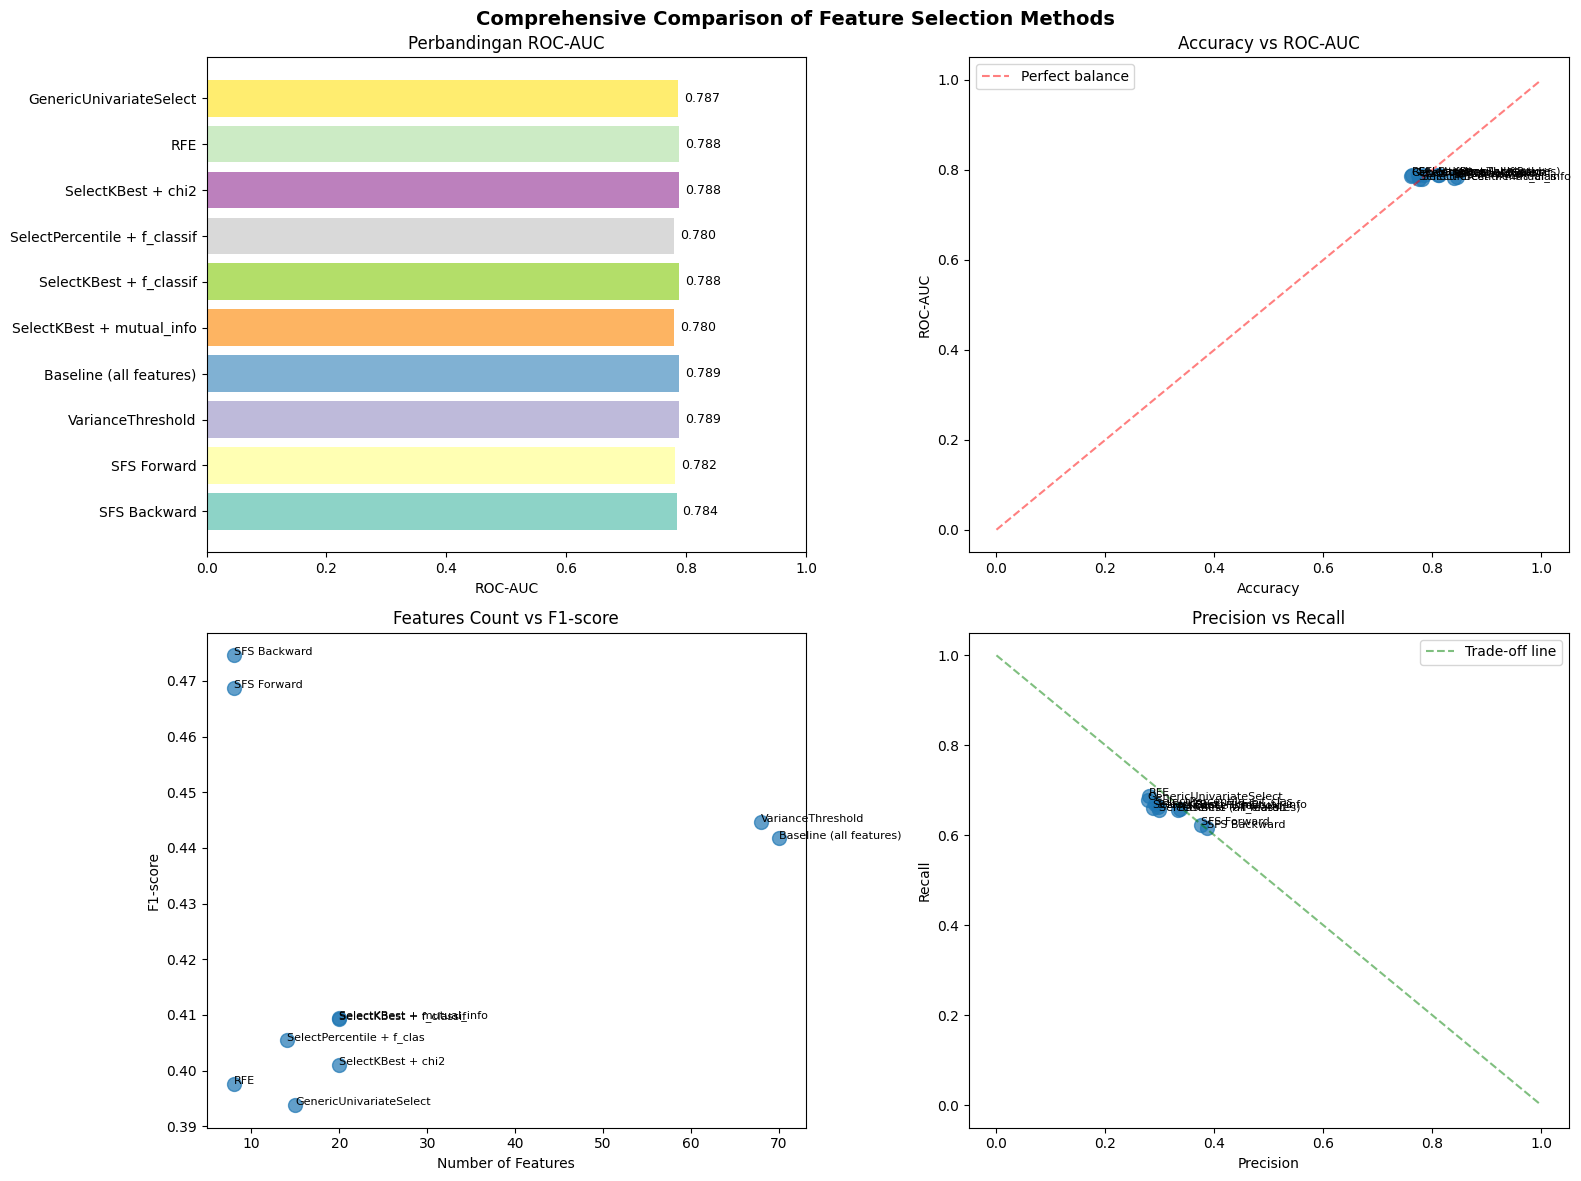


=== Summary Table ===


,method,n_features,accuracy,precision,recall,f1
0,SFS Backward,8,0.844459,0.386091,0.615679,0.474576
1,SFS Forward,8,0.838787,0.375576,0.623327,0.468728
2,VarianceThreshold,68,0.812609,0.335938,0.657744,0.444732
3,Baseline (all features),70,0.810864,0.333010,0.655832,0.441726
4,SelectKBest + mutual_info,20,0.781632,0.296075,0.663480,0.409440
5,SelectKBest + f_classif,20,0.784031,0.297485,0.655832,0.409308
6,SelectPercentile + f_classif,14,0.776178,0.290939,0.669216,0.405562
7,SelectKBest + chi2,20,0.774433,0.287614,0.661568,0.400927
8,RFE,8,0.762653,0.279813,0.686424,0.397564
9,GenericUnivariateSelect,15,0.761562,0.277344,0.678776,0.393788


In [36]:
# Visualisasi perbandingan lengkap semua metode

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: ROC-AUC comparison
ax1 = axes[0, 0]
colors = plt.cm.Set3(np.linspace(0, 1, len(summary_df)))
bars = ax1.barh(summary_df['method'], summary_df['roc_auc'], color=colors)
ax1.set_xlabel('ROC-AUC')
ax1.set_title('Perbandingan ROC-AUC')
ax1.set_xlim(0, 1)
for i, (idx, row) in enumerate(summary_df.iterrows()):
    ax1.text(row['roc_auc'] + 0.01, i, f"{row['roc_auc']:.3f}", va='center', fontsize=9)

# Plot 2: Accuracy vs ROC-AUC
ax2 = axes[0, 1]
ax2.scatter(summary_df['accuracy'], summary_df['roc_auc'], s=100, alpha=0.7)
for i, row in summary_df.iterrows():
    ax2.annotate(row['method'][:25], (row['accuracy'], row['roc_auc']), fontsize=8)
ax2.set_xlabel('Accuracy')
ax2.set_ylabel('ROC-AUC')
ax2.set_title('Accuracy vs ROC-AUC')
ax2.plot([0, 1], [0, 1], 'r--', alpha=0.5, label='Perfect balance')
ax2.legend()

# Plot 3: Number of features vs F1-score
ax3 = axes[1, 0]
ax3.scatter(summary_df['n_features'], summary_df['f1'], s=100, alpha=0.7)
for i, row in summary_df.iterrows():
    ax3.annotate(row['method'][:25], (row['n_features'], row['f1']), fontsize=8)
ax3.set_xlabel('Number of Features')
ax3.set_ylabel('F1-score')
ax3.set_title('Features Count vs F1-score')

# Plot 4: Precision-Recall tradeoff
ax4 = axes[1, 1]
ax4.scatter(summary_df['precision'], summary_df['recall'], s=100, alpha=0.7)
for i, row in summary_df.iterrows():
    ax4.annotate(row['method'][:25], (row['precision'], row['recall']), fontsize=8)
ax4.set_xlabel('Precision')
ax4.set_ylabel('Recall')
ax4.set_title('Precision vs Recall')
ax4.plot([0, 1], [1, 0], 'g--', alpha=0.5, label='Trade-off line')
ax4.legend()

plt.suptitle('Comprehensive Comparison of Feature Selection Methods', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print summary table with formatting
print('\n=== Summary Table ===')
summary_display = summary_df[['method', 'n_features', 'accuracy', 'precision', 'recall', 'f1']].copy()
summary_display = summary_display.style.background_gradient(subset=['accuracy', 'precision', 'recall', 'f1'], cmap='YlGn')
display(summary_display)


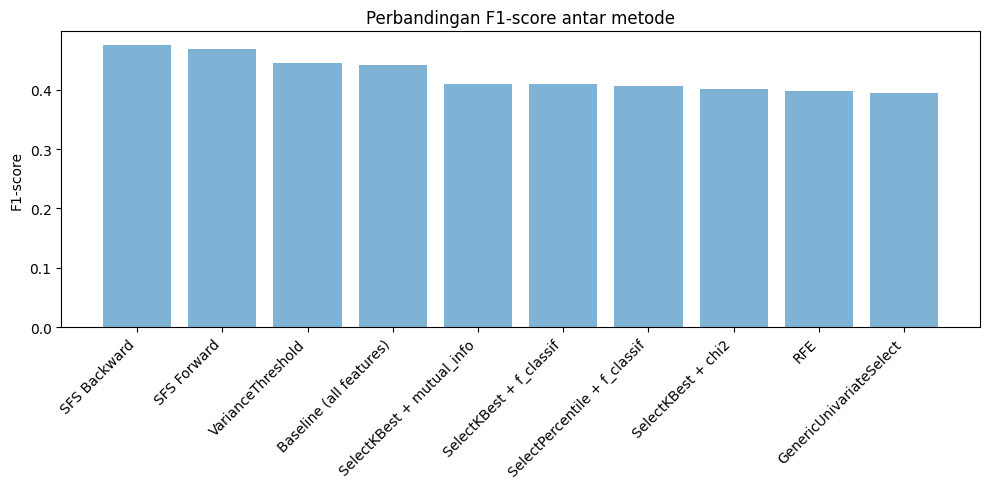

In [37]:
plt.figure(figsize=(10, 5))
plt.bar(summary_df['method'], summary_df['f1'], color='#7fb3d5')
plt.title('Perbandingan F1-score antar metode')
plt.ylabel('F1-score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [38]:
selected_feature_summary = pd.DataFrame({
    'method': list(feature_sets.keys()),
    'selected_features': [', '.join(features[:12]) + (' ...' if len(features) > 12 else '') for features in feature_sets.values()]
})
selected_feature_summary


,method,selected_features
0,Baseline (all features),"usia, jumlah_kontak_kampanye_ini, hari_sejak_k..."
1,VarianceThreshold,"usia, jumlah_kontak_kampanye_ini, hari_sejak_k..."
2,SelectKBest + f_classif,"hari_sejak_kontak_sebelumnya, jumlah_kontak_se..."
3,SelectKBest + mutual_info,"usia, hari_sejak_kontak_sebelumnya, jumlah_kon..."
4,SelectKBest + chi2,"hari_sejak_kontak_sebelumnya, jumlah_kontak_se..."
5,SelectPercentile + f_classif,"hari_sejak_kontak_sebelumnya, jumlah_kontak_se..."
6,GenericUnivariateSelect,"hari_sejak_kontak_sebelumnya, jumlah_kontak_se..."
7,SFS Forward,"jumlah_pekerja, hari_sejak_kontak_sebelumnya, ..."
8,SFS Backward,"jumlah_pekerja, hari_sejak_kontak_sebelumnya, ..."
9,RFE,"hasil_kampanye_sebelumnya_success, tingkat_var..."


### Observasi yang perlu diperhatikan

Beberapa hal yang biasanya muncul saat membandingkan hasil:

- metode filter yang berbeda bisa memilih fitur yang berbeda
- jumlah fitur lebih sedikit belum tentu memberi skor paling tinggi
- wrapper methods lebih mahal, tetapi kadang menghasilkan subset yang lebih sesuai model
- `chi2` sering kuat untuk dummy variables / fitur non-negative
- `mutual_info_classif` berguna saat hubungan fitur-target tidak cukup linear


## 8. Validasi pada Validation Set

Validation set yang disediakan tidak memiliki target. Jadi kita tidak bisa menghitung skor evaluasi final di sini. Tetapi kita tetap bisa menyiapkan fitur validation set agar pipeline konsisten.


In [39]:
X_valid_raw = df_valid.drop(columns=identifier_columns).copy()
X_valid_encoded = pd.get_dummies(X_valid_raw, columns=categorical_columns, drop_first=False, dtype=int)

# Samakan kolom dengan training set hasil encoding
X_valid_encoded = X_valid_encoded.reindex(columns=X_encoded.columns, fill_value=0)

print('Shape validation encoded:', X_valid_encoded.shape)
X_valid_encoded.head()


Shape validation encoded: (5729, 70)


,usia,jumlah_kontak_kampanye_ini,hari_sejak_kontak_sebelumnya,jumlah_kontak_sebelumnya,tingkat_variasi_pekerjaan,indeks_harga_konsumen,indeks_kepercayaan_konsumen,suku_bunga_euribor_3bln,jumlah_pekerja,pekerjaan_asisten rumah tangga,pekerjaan_entrepreneur,pekerjaan_mahasiswa,pekerjaan_manajer,pekerjaan_pekerja kasar,pekerjaan_pemilik bisnis,pekerjaan_pengangguran,pekerjaan_pensiunan,pekerjaan_penyedia jasa,pekerjaan_sosial media specialis,pekerjaan_teknisi,pekerjaan_unknown,status_perkawinan_cerai,status_perkawinan_lajang,status_perkawinan_menikah,status_perkawinan_unknown,pendidikan_Diploma,pendidikan_Pendidikan Tinggi,pendidikan_SD,pendidikan_SMA,pendidikan_SMP,pendidikan_TIDAK SEKOLAH,pendidikan_Tidak Tamat SD,pendidikan_unknown,gagal_bayar_sebelumnya_no,gagal_bayar_sebelumnya_unknown,gagal_bayar_sebelumnya_yes,pinjaman_rumah_no,pinjaman_rumah_unknown,pinjaman_rumah_yes,pinjaman_pribadi_no,pinjaman_pribadi_unknown,pinjaman_pribadi_yes,jenis_kontak_cellular,jenis_kontak_telephone,bulan_kontak_terakhir_apr,bulan_kontak_terakhir_aug,bulan_kontak_terakhir_dec,bulan_kontak_terakhir_jul,bulan_kontak_terakhir_jun,bulan_kontak_terakhir_mar,bulan_kontak_terakhir_may,bulan_kontak_terakhir_nov,bulan_kontak_terakhir_oct,bulan_kontak_terakhir_sep,hari_kontak_terakhir_fri,hari_kontak_terakhir_mon,hari_kontak_terakhir_thu,hari_kontak_terakhir_tue,hari_kontak_terakhir_wed,hasil_kampanye_sebelumnya_failure,hasil_kampanye_sebelumnya_nonexistent,hasil_kampanye_sebelumnya_success,pulau_Bali,pulau_Jawa,pulau_Kalimantan,pulau_NTB,pulau_NTT,pulau_Papua,pulau_Sulawesi,pulau_Sumatera
0,35,1,999,0,1.4,93.918,-42.7,4.960,5228.1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,1,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0
1,52,4,999,0,1.1,93.994,-36.4,4.860,5191.0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0
2,37,3,999,0,1.1,93.994,-36.4,4.856,5191.0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0
3,51,3,999,0,1.1,93.994,-36.4,4.857,5191.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1
4,45,1,999,1,-1.8,92.893,-46.2,1.327,5099.1,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1


Contoh berikut menunjukkan cara memakai subset fitur hasil `SelectKBest + f_classif` untuk menghasilkan prediksi pada validation set.


In [40]:
best_demo_features = feature_sets['SelectKBest + f_classif']

final_model = LogisticRegression(max_iter=2000, class_weight='balanced')
final_model.fit(X_encoded[best_demo_features], y)
valid_predictions = final_model.predict(X_valid_encoded[best_demo_features])

pd.Series(valid_predictions).value_counts().sort_index()


0    4686
1    1043
Name: count, dtype: int64

## 9. Latihan Mandiri

1. Ubah `k_top` dari 20 menjadi 10 dan 30. Bagaimana perubahan performanya?
2. Bandingkan fitur terpilih antara `f_classif`, `mutual_info_classif`, dan `chi2`. Mana yang paling stabil?
3. Coba `SelectPercentile` dengan `percentile=10` dan `percentile=30`.
4. Ubah jumlah fitur pada SFS dan RFE dari 8 menjadi 5. Apakah performa turun banyak?
5. Apakah fitur-fitur yang dipilih metode filter juga sering dipilih oleh wrapper methods?
6. Menurut kalian, lebih baik mengejar **fitur sedikit tapi interpretable** atau **fitur lebih banyak tapi sedikit lebih akurat**? Jelaskan.


---

## 10. Approach Tambahan: Feature Engineering + Grouping Features

Pada bagian ini, kita akan mencoba approach yang lebih advanced dengan:
1. **Feature Engineering** - membuat interaction features
2. **Grouping Features** - mengelompokkan kategori pendidikan dan pekerjaan
3. **Drop Fitur Tidak Penting** - mengurangi dimensi dengan domain knowledge
4. **Ordinal Encoding** - encoding kategorikal dengan ordinal

Approach ini didasarkan pada teknik yang digunakan dalam kompetisi data science.


In [41]:
# Additional imports for feature engineering
from sklearn.preprocessing import OrdinalEncoder
import numpy as np

# Make copies of original data for this approach
train_df = df.copy()
test_df = df_valid.copy()
val_df = df_valid.copy()  # Validation set for feature engineering

print('Original training shape:', train_df.shape)
print('Original validation shape:', test_df.shape)


Original training shape: (22916, 22)
Original validation shape: (5729, 21)


### 10.1 Feature Engineering - Interaction Features dengan Suku Bunga

Membuat interaction features antara suku bunga dengan fitur lainnya untuk menangkap efek kombinasi.


In [42]:
# FEATURE SUKU BUNGA - Interaction Features

# Interaksi fitur bunga x kontak kampanye
train_df['bunga_x_kontak'] = train_df['suku_bunga_euribor_3bln'] * train_df['jumlah_kontak_kampanye_ini']
test_df['bunga_x_kontak'] = test_df['suku_bunga_euribor_3bln'] * test_df['jumlah_kontak_kampanye_ini']
val_df['bunga_x_kontak'] = val_df['suku_bunga_euribor_3bln'] * val_df['jumlah_kontak_kampanye_ini']

# Interaksi fitur bunga x jumlah pekerja
train_df['bunga_x_pekerja'] = train_df['suku_bunga_euribor_3bln'] * train_df['jumlah_pekerja']
test_df['bunga_x_pekerja'] = test_df['suku_bunga_euribor_3bln'] * test_df['jumlah_pekerja']
val_df['bunga_x_pekerja'] = val_df['suku_bunga_euribor_3bln'] * val_df['jumlah_pekerja']

# Interaksi fitur bunga x indeks kepercayaan konsumen
train_df['bunga_x_kepercayaan'] = train_df['suku_bunga_euribor_3bln'] * train_df['indeks_kepercayaan_konsumen']
test_df['bunga_x_kepercayaan'] = test_df['suku_bunga_euribor_3bln'] * test_df['indeks_kepercayaan_konsumen']
val_df['bunga_x_kepercayaan'] = val_df['suku_bunga_euribor_3bln'] * val_df['indeks_kepercayaan_konsumen']

# Interaksi fitur usia x suku bunga
train_df['usia_x_suku_bunga'] = train_df['usia'] * train_df['suku_bunga_euribor_3bln']
test_df['usia_x_suku_bunga'] = test_df['usia'] * test_df['suku_bunga_euribor_3bln']
val_df['usia_x_suku_bunga'] = val_df['usia'] * val_df['suku_bunga_euribor_3bln']

print('New interaction features created:')
print('  - bunga_x_kontak')
print('  - bunga_x_pekerja')
print('  - bunga_x_kepercayaan')
print('  - usia_x_suku_bunga')
print(f'\nNew training shape: {train_df.shape}')


New interaction features created:
  - bunga_x_kontak
  - bunga_x_pekerja
  - bunga_x_kepercayaan
  - usia_x_suku_bunga

New training shape: (22916, 26)


### 10.2 Grouping Features - Mengelompokkan Kategori

Mengelompokkan kategori pendidikan dan pekerjaan untuk mengurangi dimensi dan noise.


In [43]:
# GROUPING FEATURE - Pendidikan

def group_pendidikan(x):
    if pd.isna(x):
        return 'Unknown'
    x = str(x).strip().lower()
    if x in ['pendidikan tinggi', 'diploma']:
        return 'High Education'
    elif x in ['sma', 'smp']:
        return 'Secondary School'
    elif x == 'sd':
        return 'Primary School'
    elif x in ['tidak tamat sd', 'tidak sekolah']:
        return 'No Formal School'
    else:
        return 'unknown'

train_df['pendidikan_group'] = train_df['pendidikan'].apply(group_pendidikan)
test_df['pendidikan_group'] = test_df['pendidikan'].apply(group_pendidikan)
val_df['pendidikan_group'] = val_df['pendidikan'].apply(group_pendidikan)

print('Pendidikan grouping created')
print('Unique groups:', train_df['pendidikan_group'].unique())


Pendidikan grouping created
Unique groups: ['High Education' 'Secondary School' 'No Formal School' 'Primary School'
 'unknown']


In [44]:
# GROUPING FEATURE - Pekerjaan

def group_pekerjaan(x):
    if pd.isna(x):
        return 'unknown'
    x = str(x).strip().lower()
    if x in ['sosial media specialis', 'manajer', 'teknisi']:
        return 'Professional'
    elif x in ['pekerja kasar', 'asisten rumah tangga']:
        return 'Labor/Manual'
    elif x in ['pemilik bisnis', 'entrepreneur']:
        return 'Business Owner'
    elif x == 'penyedia jasa':
        return 'Service Provider'
    elif x == 'mahasiswa':
        return 'Student'
    elif x in ['pensiunan', 'pengangguran']:
        return 'Retired/Unemployed'
    else:
        return 'unknown'

train_df['pekerjaan_group'] = train_df['pekerjaan'].apply(group_pekerjaan)
test_df['pekerjaan_group'] = test_df['pekerjaan'].apply(group_pekerjaan)
val_df['pekerjaan_group'] = val_df['pekerjaan'].apply(group_pekerjaan)

print('Pekerjaan grouping created')
print('Unique groups:', train_df['pekerjaan_group'].unique())


Pekerjaan grouping created
Unique groups: ['Professional' 'Labor/Manual' 'Student' 'Service Provider'
 'Business Owner' 'Retired/Unemployed' 'unknown']


### 10.3 Data Processing - Drop Fitur dan Encoding

Menghapus fitur yang tidak penting dan melakukan ordinal encoding.


In [45]:
# DROP FEATURE - Hapus fitur tidak penting

# Drop identifier dan fitur yang tidak informatif
train_df.drop(columns=['customer_number', 'pulau'], inplace=True)
test_df.drop(columns=['customer_number', 'pulau'], inplace=True)

# Drop kolom original yang sudah di-group atau tidak penting
drop_cols = [
    'pekerjaan',
    'pendidikan',
    "gagal_bayar_sebelumnya",
    "bulan_kontak_terakhir",
    "hari_kontak_terakhir",
    "tingkat_variasi_pekerjaan"
]

train_df.drop(columns=drop_cols, inplace=True)
test_df.drop(columns=drop_cols, inplace=True)
val_df.drop(columns=drop_cols, inplace=True)

print('Dropped columns:', drop_cols)
print(f'\nTraining shape after drop: {train_df.shape}')
print(f'Validation shape after drop: {test_df.shape}')


Dropped columns: ['pekerjaan', 'pendidikan', 'gagal_bayar_sebelumnya', 'bulan_kontak_terakhir', 'hari_kontak_terakhir', 'tingkat_variasi_pekerjaan']

Training shape after drop: (22916, 20)
Validation shape after drop: (5729, 19)


In [46]:
# ORDINAL ENCODING - Encode semua fitur kategorikal

# Prepare validation set properly
val_df = df_valid.copy()

# Recreate interaction features for validation
val_df['bunga_x_kontak'] = val_df['suku_bunga_euribor_3bln'] * val_df['jumlah_kontak_kampanye_ini']
val_df['bunga_x_pekerja'] = val_df['suku_bunga_euribor_3bln'] * val_df['jumlah_pekerja']
val_df['bunga_x_kepercayaan'] = val_df['suku_bunga_euribor_3bln'] * val_df['indeks_kepercayaan_konsumen']
val_df['usia_x_suku_bunga'] = val_df['usia'] * val_df['suku_bunga_euribor_3bln']

# Recreate grouping features for validation
val_df['pendidikan_group'] = val_df['pendidikan'].apply(group_pendidikan)
val_df['pekerjaan_group'] = val_df['pekerjaan'].apply(group_pekerjaan)

# Drop same columns
val_df.drop(columns=['customer_number', 'pulau'] + drop_cols, inplace=True)

# Ordinal encode all categorical features
categorical_features = train_df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f'Categorical features to encode: {len(categorical_features)}')
print(categorical_features)

encoders = {}
for feature in categorical_features:
    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    # Reshape for sklearn (expects 2D)
    train_vals = train_df[[feature]]
    test_vals = test_df[[feature]]
    val_vals = val_df[[feature]]
    
    # Fit encoder on training data and transform all sets
    train_df[feature] = encoder.fit_transform(train_vals)
    test_df[feature] = encoder.transform(test_vals)
    val_df[feature] = encoder.transform(val_vals)
    
    encoders[feature] = encoder

print(f'\nEncoded {len(categorical_features)} categorical features')
print(f'\nFinal training shape: {train_df.shape}')


Categorical features to encode: 7
['status_perkawinan', 'pinjaman_rumah', 'pinjaman_pribadi', 'jenis_kontak', 'hasil_kampanye_sebelumnya', 'pendidikan_group', 'pekerjaan_group']

Encoded 7 categorical features

Final training shape: (22916, 20)


### 10.4 Modeling dengan Feature Engineering Approach

Sekarang kita akan melatih model dengan fitur yang sudah di-engineer dan bandingkan dengan approach sebelumnya.


In [47]:
# Prepare data for modeling
X_train_fe = train_df.drop(columns=['berlangganan_deposito']).copy()
y_train_fe = train_df['berlangganan_deposito'].astype(int)

# Note: test_df and val_df are validation sets without target
# We'll use train-test split from training data for evaluation
from sklearn.model_selection import train_test_split

X_train_fe_split, X_test_fe_split, y_train_fe_split, y_test_fe_split = train_test_split(
    X_train_fe, y_train_fe, test_size=0.2, random_state=42, stratify=y_train_fe
)

# For validation set (no target)
X_val_fe = val_df.copy()

print('Training split shape:', X_train_fe_split.shape)
print('Test split shape:', X_test_fe_split.shape)
print('Validation set shape:', X_val_fe.shape)

# Multiple models to compare
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42)
}

fe_results = []

for name, model in models.items():
    model.fit(X_train_fe_split, y_train_fe_split)
    y_pred = model.predict(X_test_fe_split)
    
    try:
        y_pred_proba = model.predict_proba(X_test_fe_split)
        if len(y_pred_proba.shape) == 2 and y_pred_proba.shape[1] == 2:
            roc_auc = roc_auc_score(y_test_fe_split, y_pred_proba[:, 1])
        else:
            roc_auc = roc_auc_score(y_test_fe_split, y_pred_proba, multi_class='ovr', average='macro')
    except:
        roc_auc = float('nan')
    
    result = {
        'model': name,
        'accuracy': accuracy_score(y_test_fe_split, y_pred),
        'precision': precision_score(y_test_fe_split, y_pred, zero_division=0),
        'recall': recall_score(y_test_fe_split, y_pred, zero_division=0),
        'f1': f1_score(y_test_fe_split, y_pred, zero_division=0),
        'roc_auc': roc_auc
    }
    fe_results.append(result)
    print(f'{name}: ROC-AUC = {roc_auc:.4f}')

fe_results_df = pd.DataFrame(fe_results).sort_values('roc_auc', ascending=False)
print('\n=== Feature Engineering Approach Results ===')
display(fe_results_df)


Training split shape: (18332, 19)
Test split shape: (4584, 19)
Validation set shape: (5729, 19)


Logistic Regression: ROC-AUC = 0.7706


Random Forest: ROC-AUC = 0.7874


Gradient Boosting: ROC-AUC = 0.7913

=== Feature Engineering Approach Results ===


,model,accuracy,precision,recall,f1,roc_auc
2,Gradient Boosting,0.898997,0.625000,0.286807,0.393185,0.791332
1,Random Forest,0.867365,0.441379,0.611855,0.512821,0.787441
0,Logistic Regression,0.771815,0.285831,0.667304,0.400229,0.770619


### 10.5 Perbandingan: Feature Engineering vs Filter/Wrapper Methods

Mari kita bandingkan hasil feature engineering approach dengan metode filter dan wrapper sebelumnya.


=== COMPARISON: All Approaches ===
Sorted by ROC-AUC (descending)



,model,approach,accuracy,precision,recall,f1,roc_auc
0,Gradient Boosting,Feature Engineering,0.898997,0.625000,0.286807,0.393185,0.791332
1,Baseline (all features),Filter/Wrapper,0.810864,0.333010,0.655832,0.441726,0.788668
2,VarianceThreshold,Filter/Wrapper,0.812609,0.335938,0.657744,0.444732,0.788598
3,RFE,Filter/Wrapper,0.762653,0.279813,0.686424,0.397564,0.788201
4,SelectKBest + chi2,Filter/Wrapper,0.774433,0.287614,0.661568,0.400927,0.787878
5,SelectKBest + f_classif,Filter/Wrapper,0.784031,0.297485,0.655832,0.409308,0.787612
6,Random Forest,Feature Engineering,0.867365,0.441379,0.611855,0.512821,0.787441
7,GenericUnivariateSelect,Filter/Wrapper,0.761562,0.277344,0.678776,0.393788,0.787053
8,SFS Backward,Filter/Wrapper,0.844459,0.386091,0.615679,0.474576,0.784107
9,SFS Forward,Filter/Wrapper,0.838787,0.375576,0.623327,0.468728,0.781627


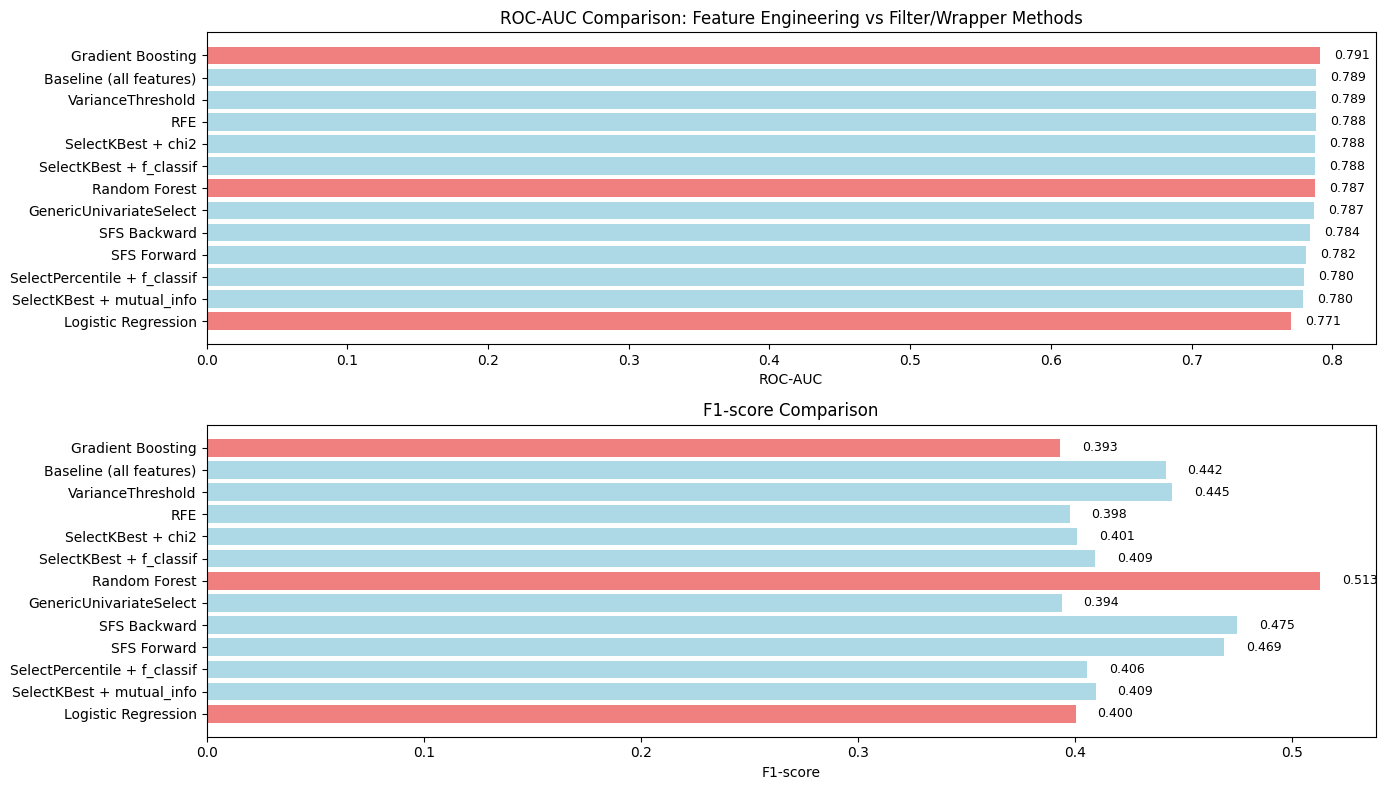


=== Top 5 Best Models by ROC-AUC ===


,model,approach,accuracy,precision,recall,f1,roc_auc
0,Gradient Boosting,Feature Engineering,0.898997,0.625000,0.286807,0.393185,0.791332
1,Baseline (all features),Filter/Wrapper,0.810864,0.333010,0.655832,0.441726,0.788668
2,VarianceThreshold,Filter/Wrapper,0.812609,0.335938,0.657744,0.444732,0.788598
3,RFE,Filter/Wrapper,0.762653,0.279813,0.686424,0.397564,0.788201
4,SelectKBest + chi2,Filter/Wrapper,0.774433,0.287614,0.661568,0.400927,0.787878



=== Best Feature Engineering Model vs Best Filter/Wrapper Model ===


,Metric,Feature Engineering,Filter/Wrapper
0,ROC-AUC,0.791332,0.788668
1,Accuracy,0.898997,0.810864
2,Precision,0.625000,0.333010
3,Recall,0.286807,0.655832
4,F1-score,0.393185,0.441726



ROC-AUC Improvement: +0.34%


In [48]:
# Combine all results for comparison

# Get best results from filter/wrapper methods
best_fw_results = pd.DataFrame(results)[['method', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']].copy()
best_fw_results['approach'] = 'Filter/Wrapper'
best_fw_results = best_fw_results.rename(columns={'method': 'model'})

# Add feature engineering results
fe_results_df['approach'] = 'Feature Engineering'

# Combine
all_results = pd.concat([
    best_fw_results[['model', 'approach', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']],
    fe_results_df[['model', 'approach', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']]
], ignore_index=True)

# Sort by ROC-AUC
all_results = all_results.sort_values('roc_auc', ascending=False).reset_index(drop=True)

print('=== COMPARISON: All Approaches ===')
print('Sorted by ROC-AUC (descending)\n')
display(all_results)

# Visualize comparison
plt.figure(figsize=(14, 8))

# Plot 1: ROC-AUC comparison
plt.subplot(2, 1, 1)
colors = ['lightblue' if x == 'Filter/Wrapper' else 'lightcoral' for x in all_results['approach']]
bars = plt.barh(range(len(all_results)), all_results['roc_auc'], color=colors)
plt.yticks(range(len(all_results)), all_results['model'])
plt.xlabel('ROC-AUC')
plt.title('ROC-AUC Comparison: Feature Engineering vs Filter/Wrapper Methods')
plt.gca().invert_yaxis()

# Add value labels
for i, v in enumerate(all_results['roc_auc']):
    if not np.isnan(v):
        plt.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

# Plot 2: F1-score comparison
plt.subplot(2, 1, 2)
bars = plt.barh(range(len(all_results)), all_results['f1'], color=colors)
plt.yticks(range(len(all_results)), all_results['model'])
plt.xlabel('F1-score')
plt.title('F1-score Comparison')
plt.gca().invert_yaxis()

# Add value labels
for i, v in enumerate(all_results['f1']):
    plt.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print('\n=== Top 5 Best Models by ROC-AUC ===')
display(all_results.head(5))

print('\n=== Best Feature Engineering Model vs Best Filter/Wrapper Model ===')
best_fe = fe_results_df.loc[fe_results_df['roc_auc'].idxmax()]
best_fw = best_fw_results.loc[best_fw_results['roc_auc'].idxmax()]

comparison_df = pd.DataFrame({
    'Metric': ['ROC-AUC', 'Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Feature Engineering': [best_fe['roc_auc'], best_fe['accuracy'], best_fe['precision'], best_fe['recall'], best_fe['f1']],
    'Filter/Wrapper': [best_fw['roc_auc'], best_fw['accuracy'], best_fw['precision'], best_fw['recall'], best_fw['f1']]
})

display(comparison_df)

# Calculate improvement
improvement = (best_fe['roc_auc'] - best_fw['roc_auc']) / best_fw['roc_auc'] * 100
print(f'\nROC-AUC Improvement: {improvement:+.2f}%')
